# Исследование зависимости значений метрик от размерности пространства.

In [36]:
import importlib
import sys
from pathlib import Path

mainPath = Path.cwd().resolve().parent
if str(mainPath) not in sys.path:
	sys.path.insert(0, str(mainPath))

import gd_experiments as gdExperiments
importlib.reload(gdExperiments)

from gd_experiments import (
    compileGd,
    setupPlotStyle,
    runTest,
    runTests,
    plotMetrics,
    renderRun,
    displayTwo,
)

In [26]:
compileGd(mainPath)

-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /Users/user/Code/Repos/GraphDrawing/build
[100%] Built target graph_drawing


In [27]:
setupPlotStyle()

Сначала тестирование будет на базовых представителях различных типов графов:

In [20]:
import json
from types import SimpleNamespace

datasetPath = mainPath / "samples" / "baseDataset.json"
with open(datasetPath, encoding="utf-8") as f:
	dataset = json.load(f)

graphs = [
	# SimpleNamespace(
	# 	name=item["name"],
	# 	nodes=list(item["nodes"]),
	# 	edges=[tuple(e) for e in item["edges"]],
	# 	raw=item,
	# )
	item["name"] for item in dataset
]

print("graphs:", len(graphs))
print([g for g in graphs])

graphs: 10
['baseTreePath', 'baseTreeStar', 'baseTreeBinary', 'baseBipartiteComplete', 'baseBipartiteLadder', 'basePlanarWheel', 'basePlanarTriangulated', 'baseDisconnected', 'baseComplete', 'baseCommunity']


Для начала будут сравниваться результаты при обычной ортогональной проекции. Из-за того, что координаты просто отбрасываются повышение размерности почти не будет влиять на результат.

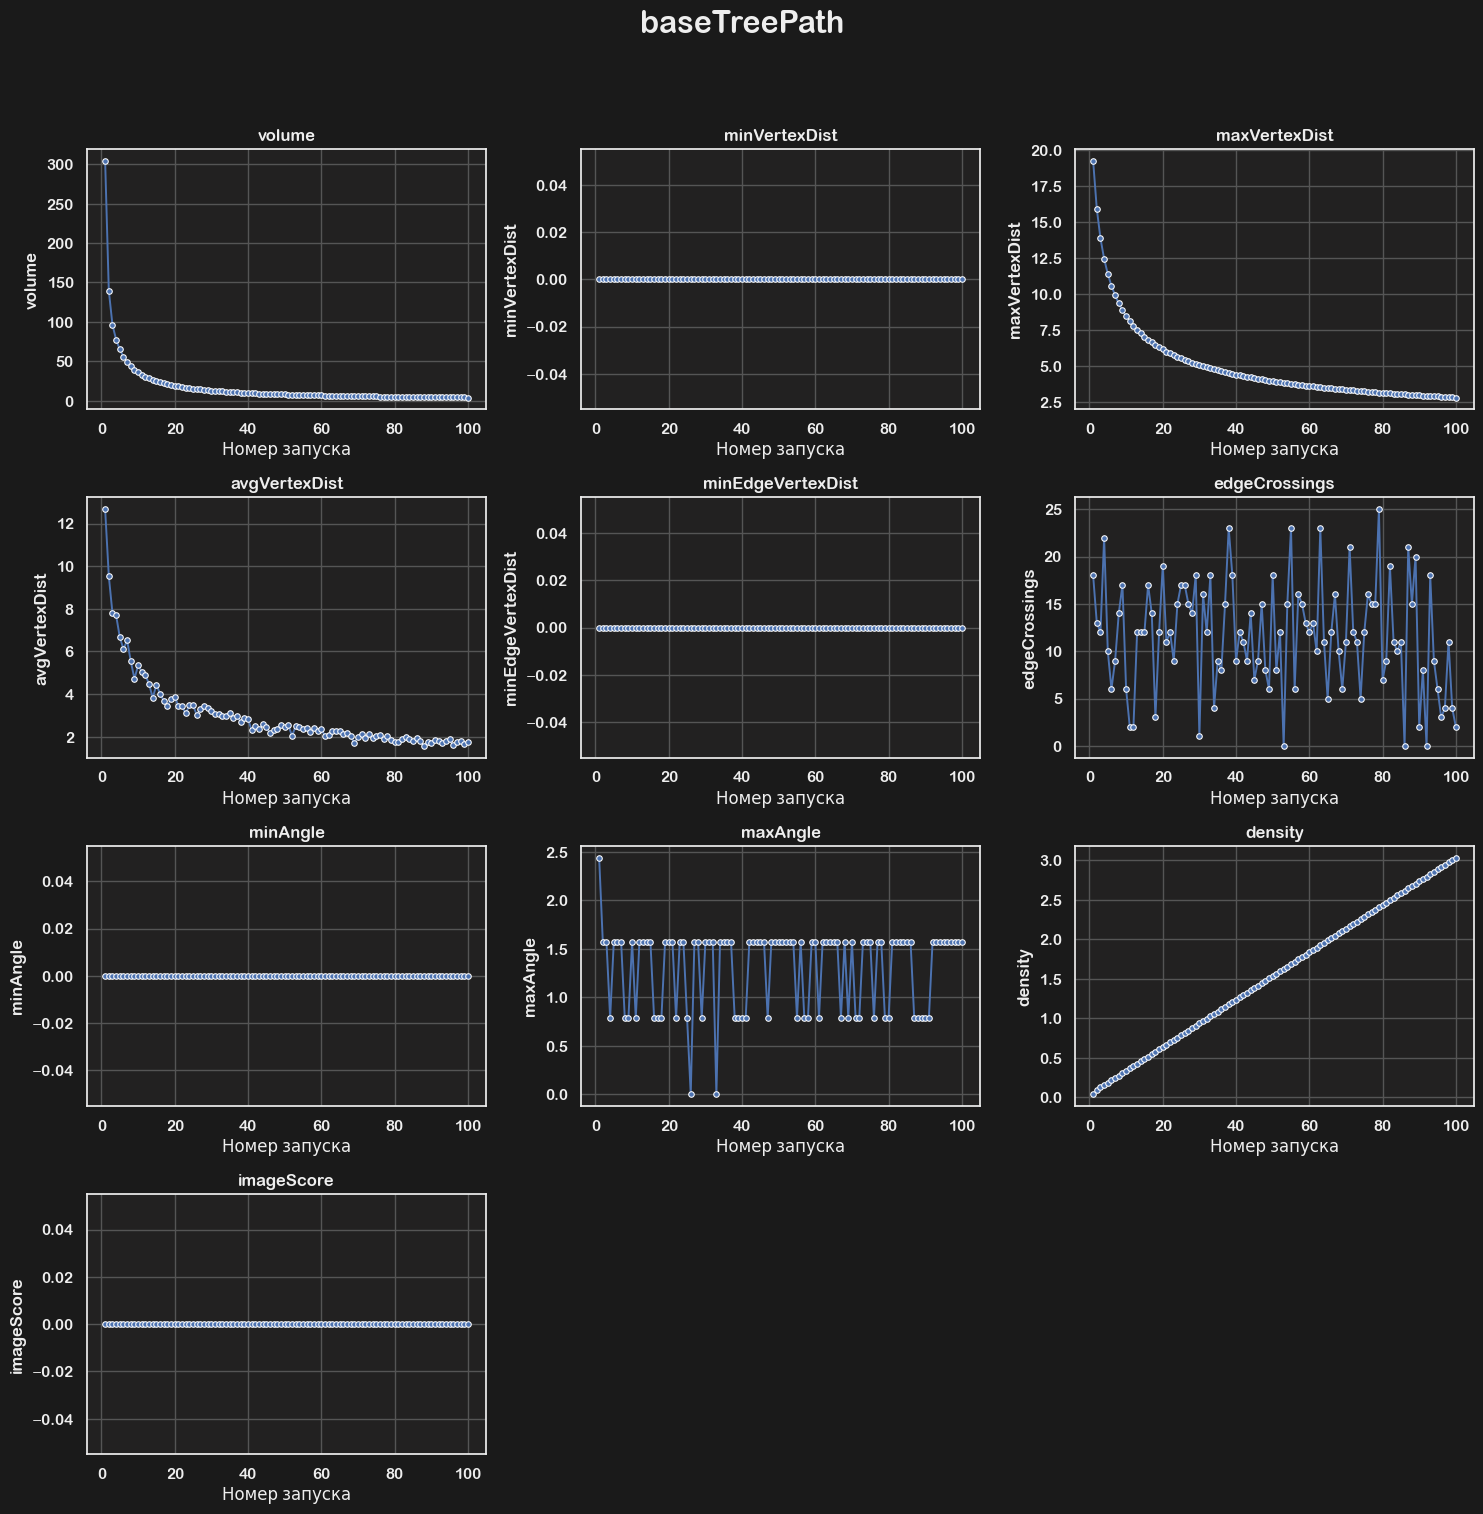

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


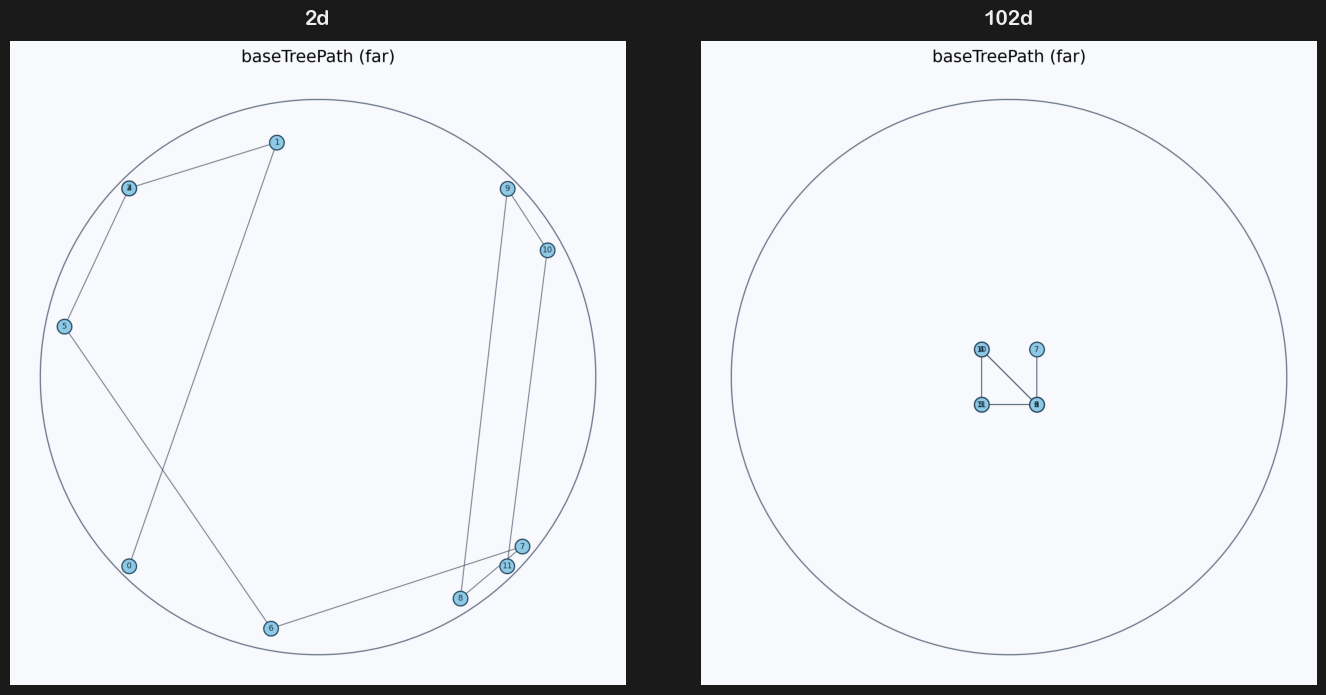

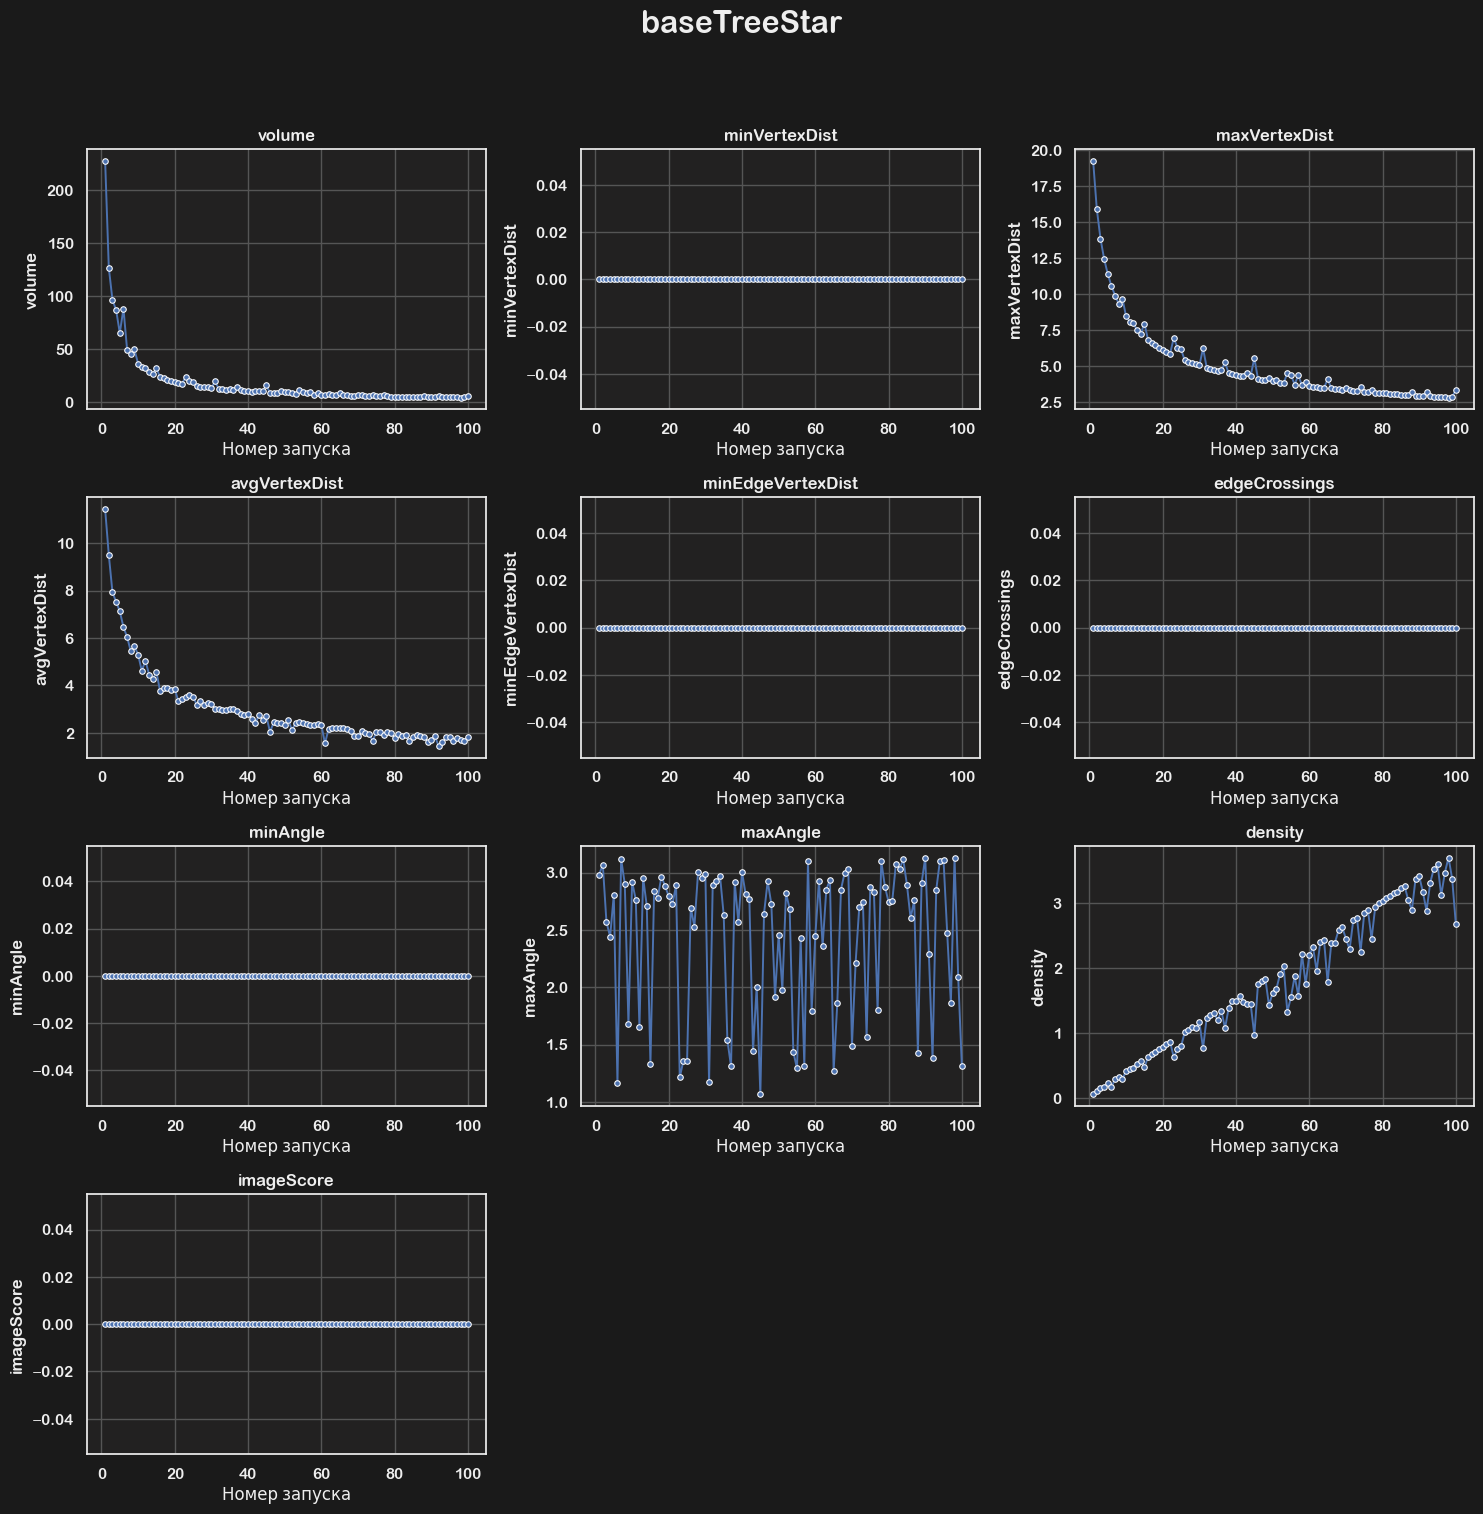

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


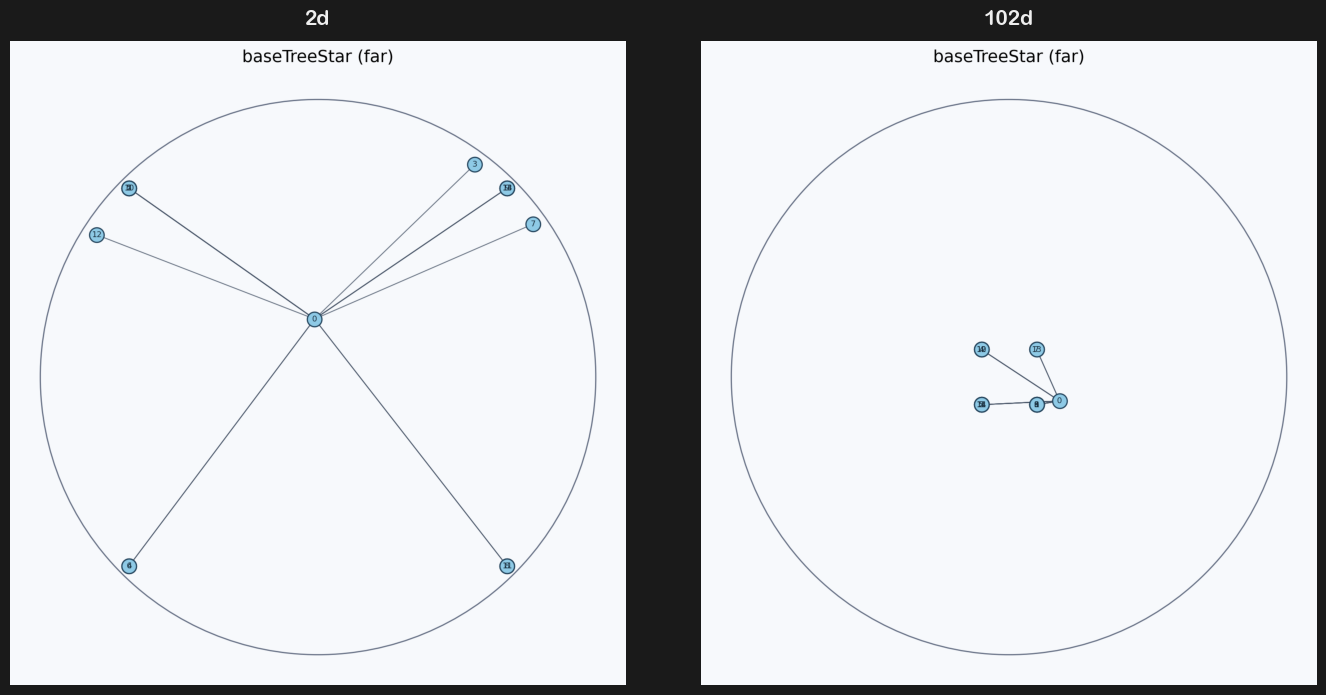

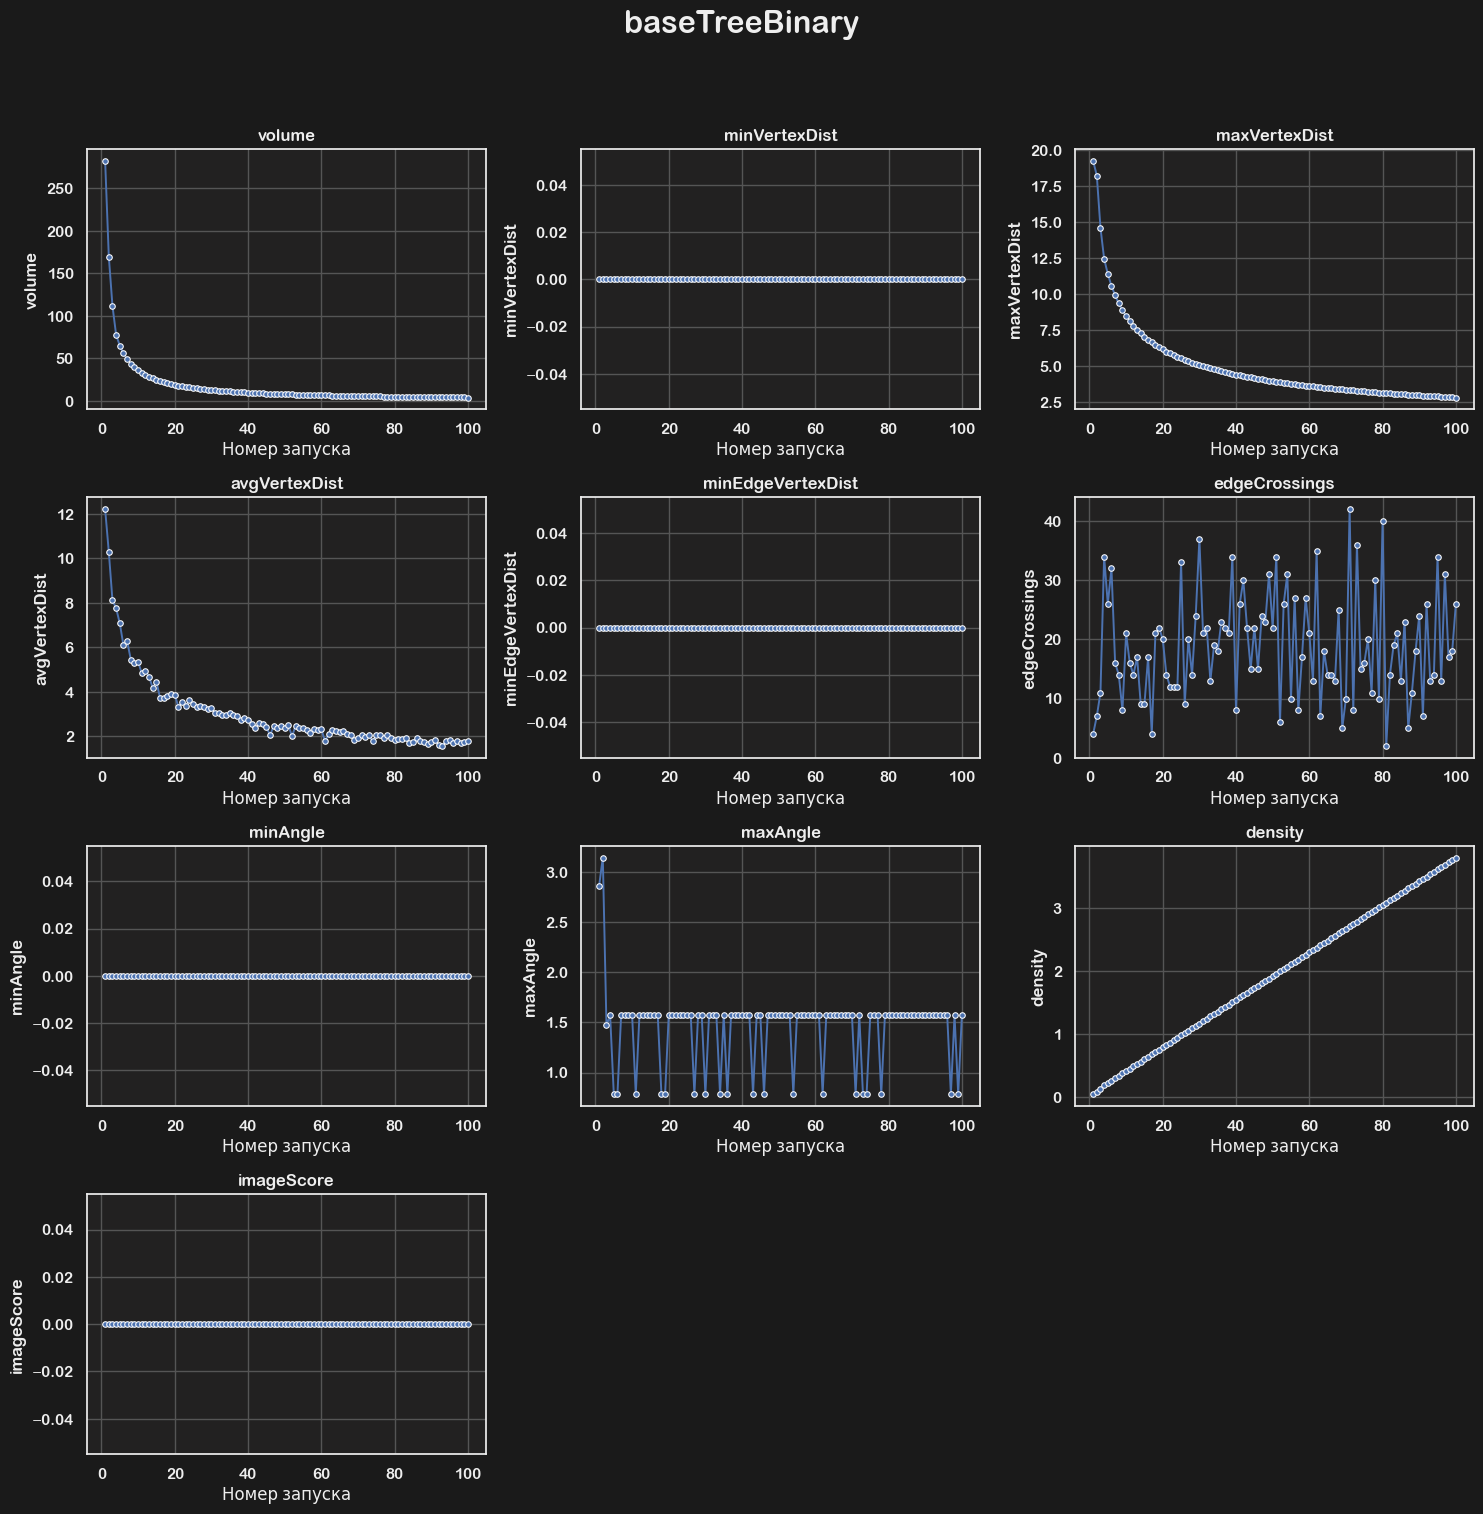

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


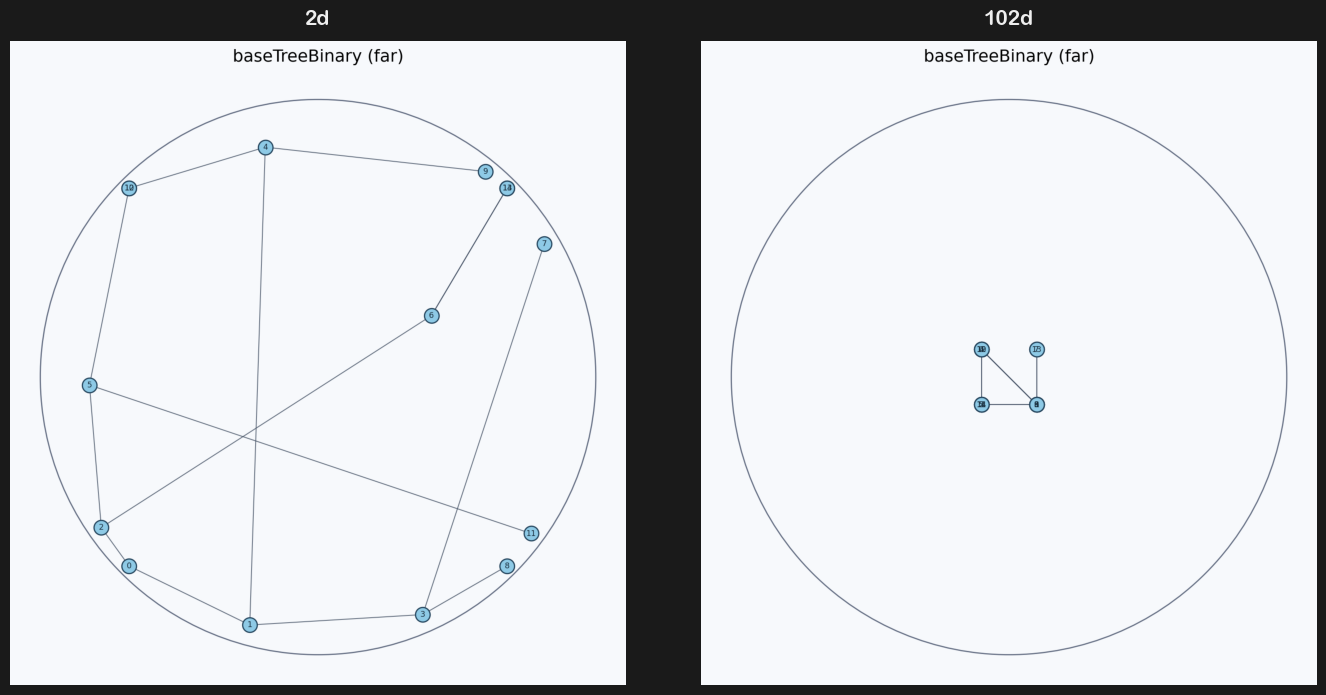

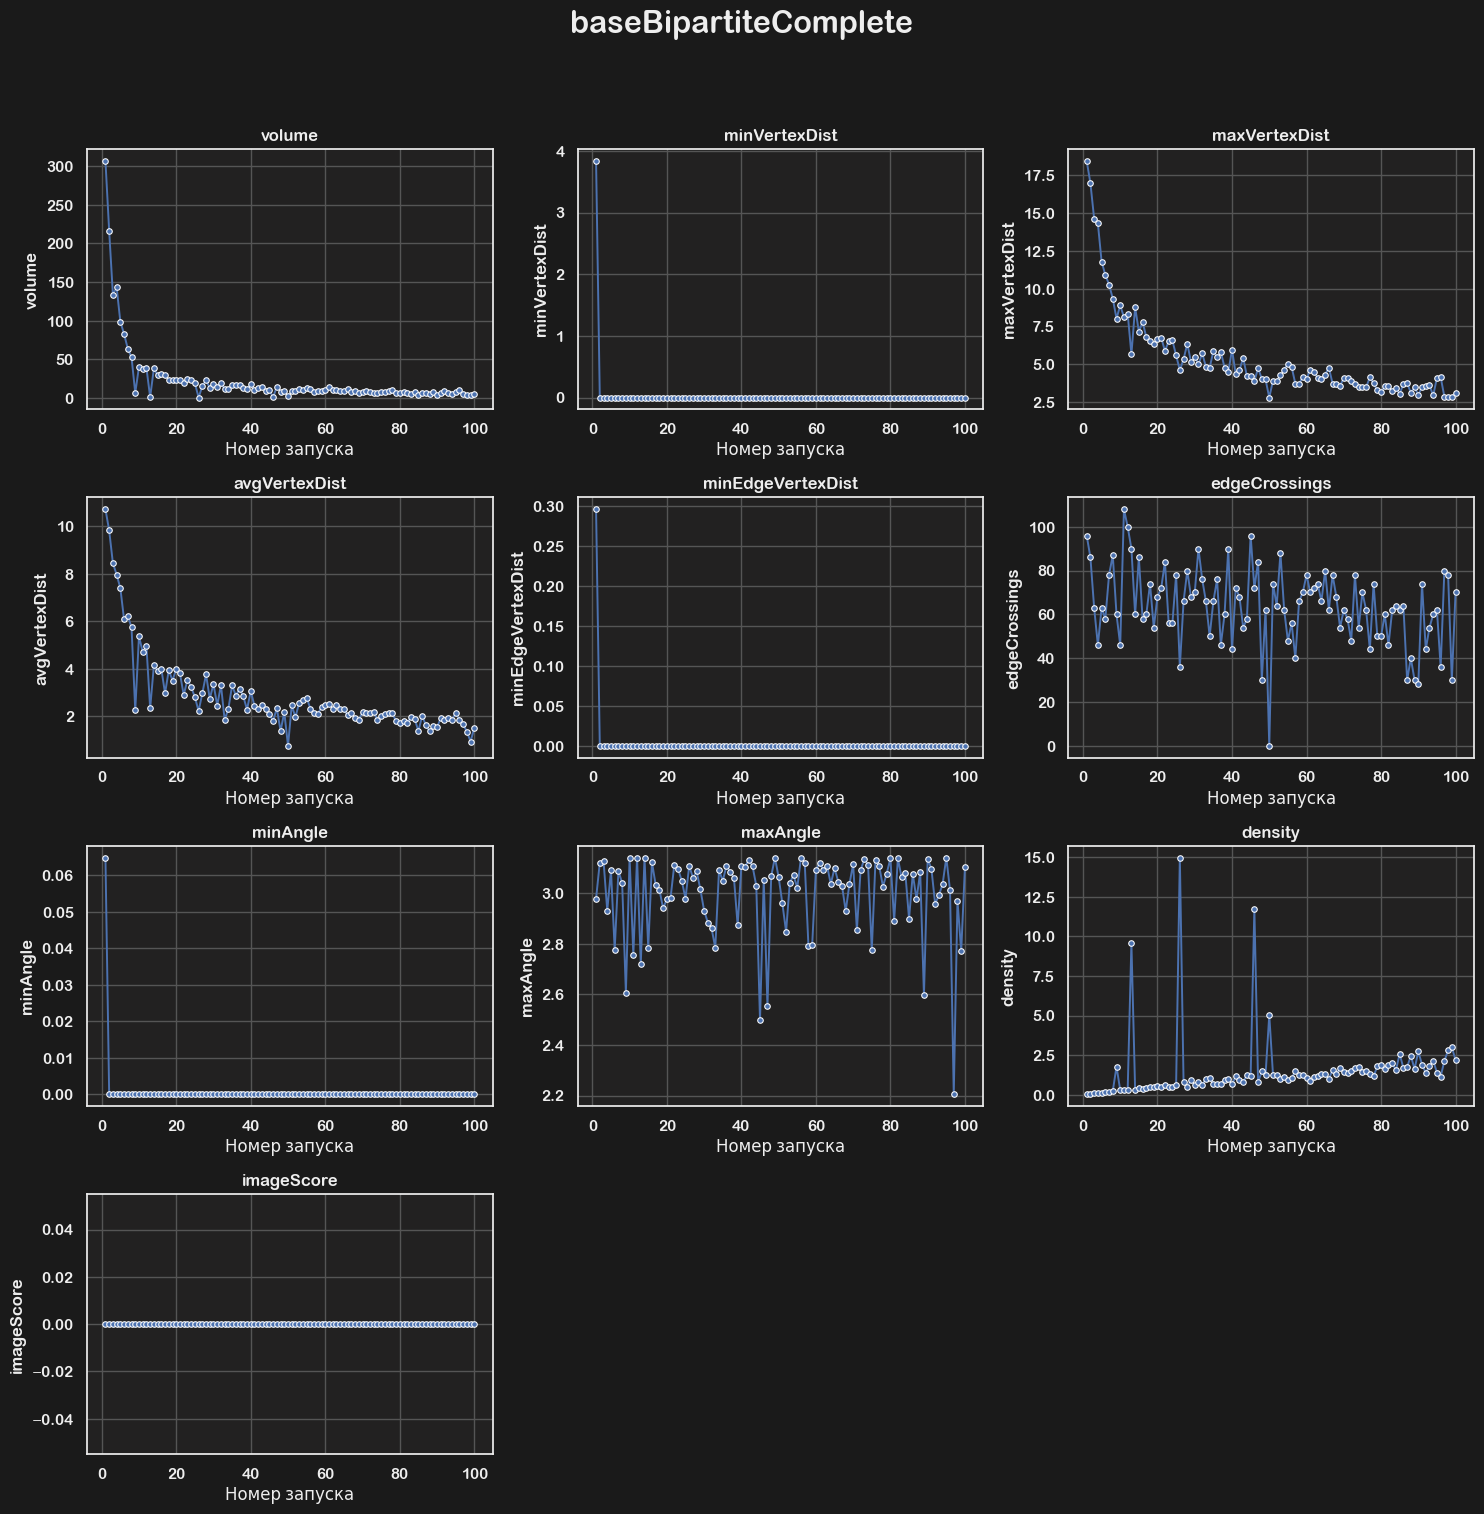

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


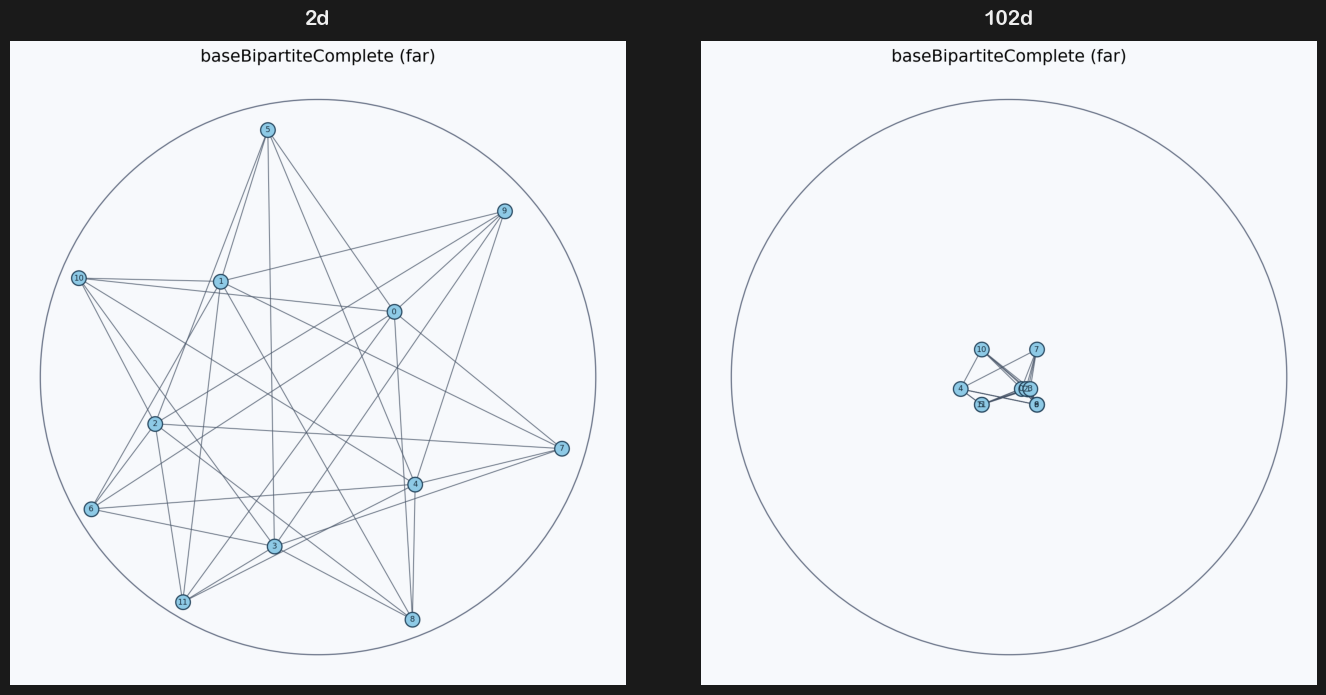

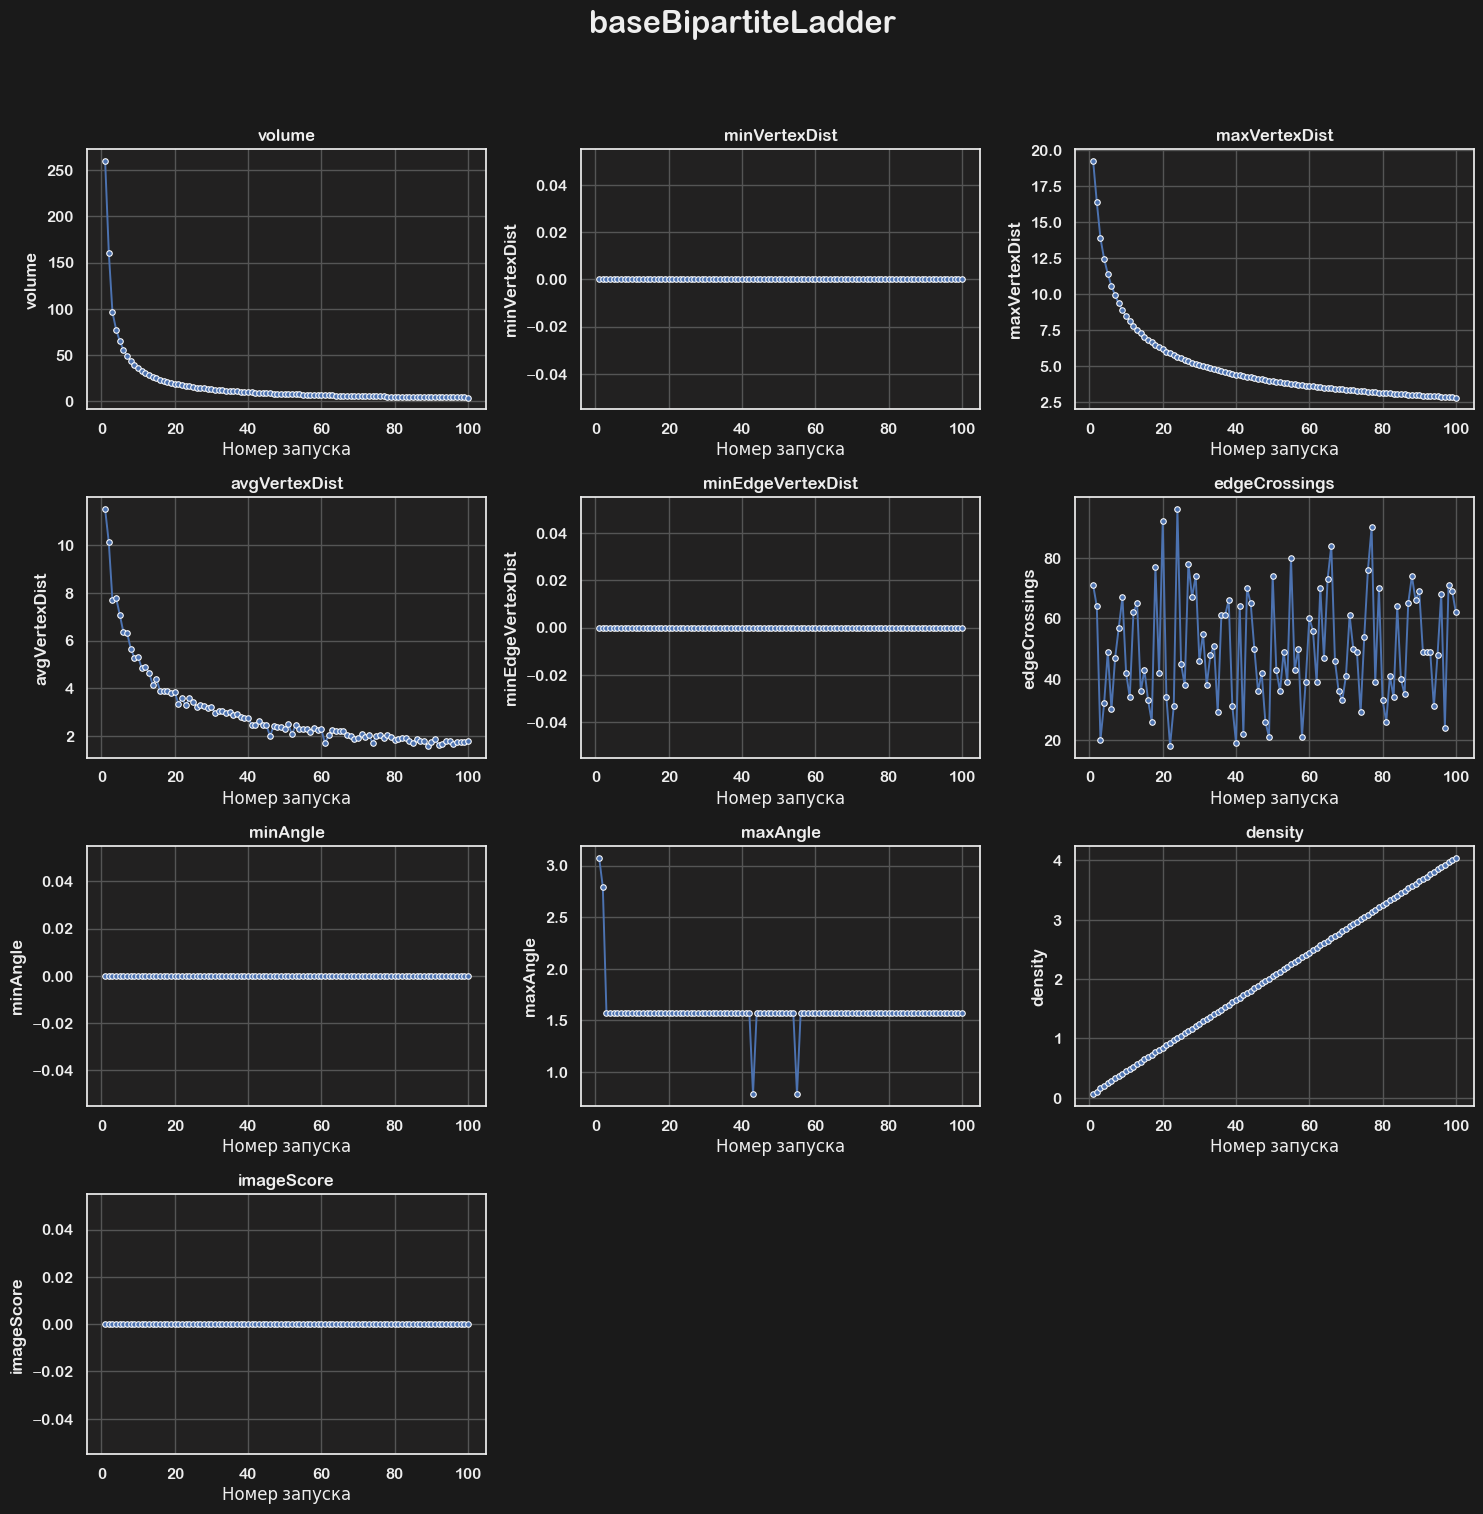

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


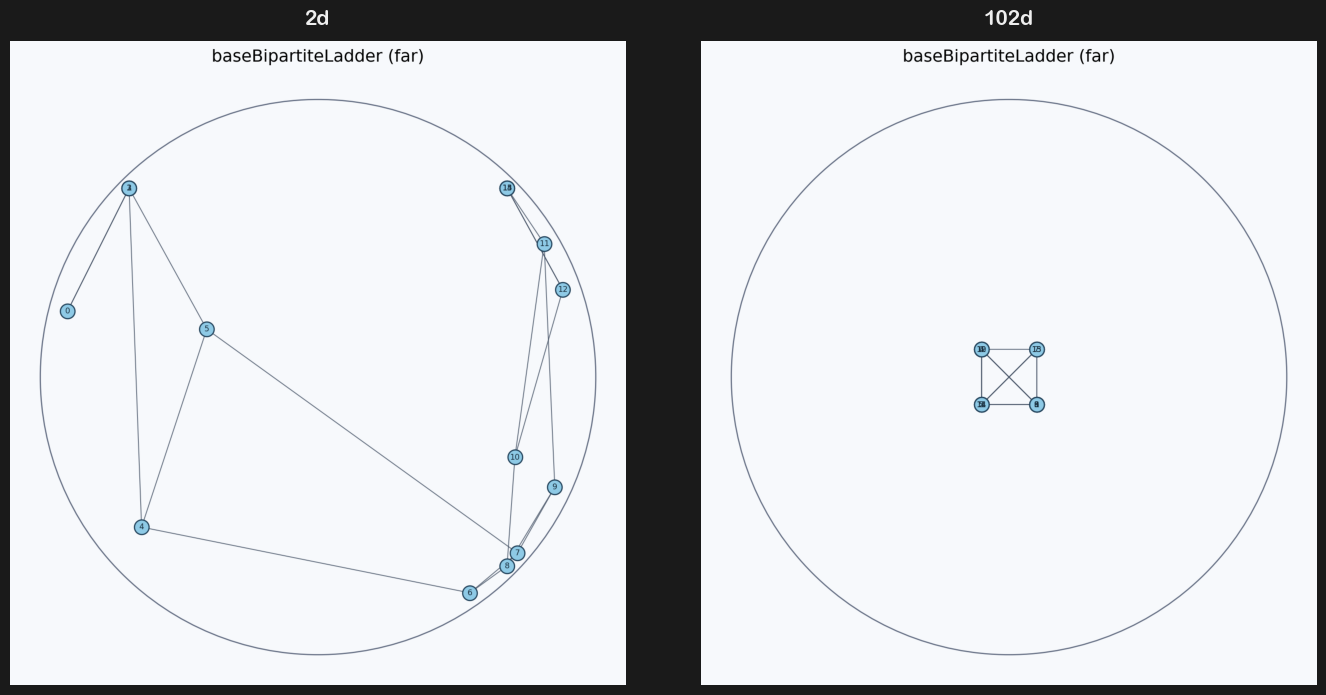

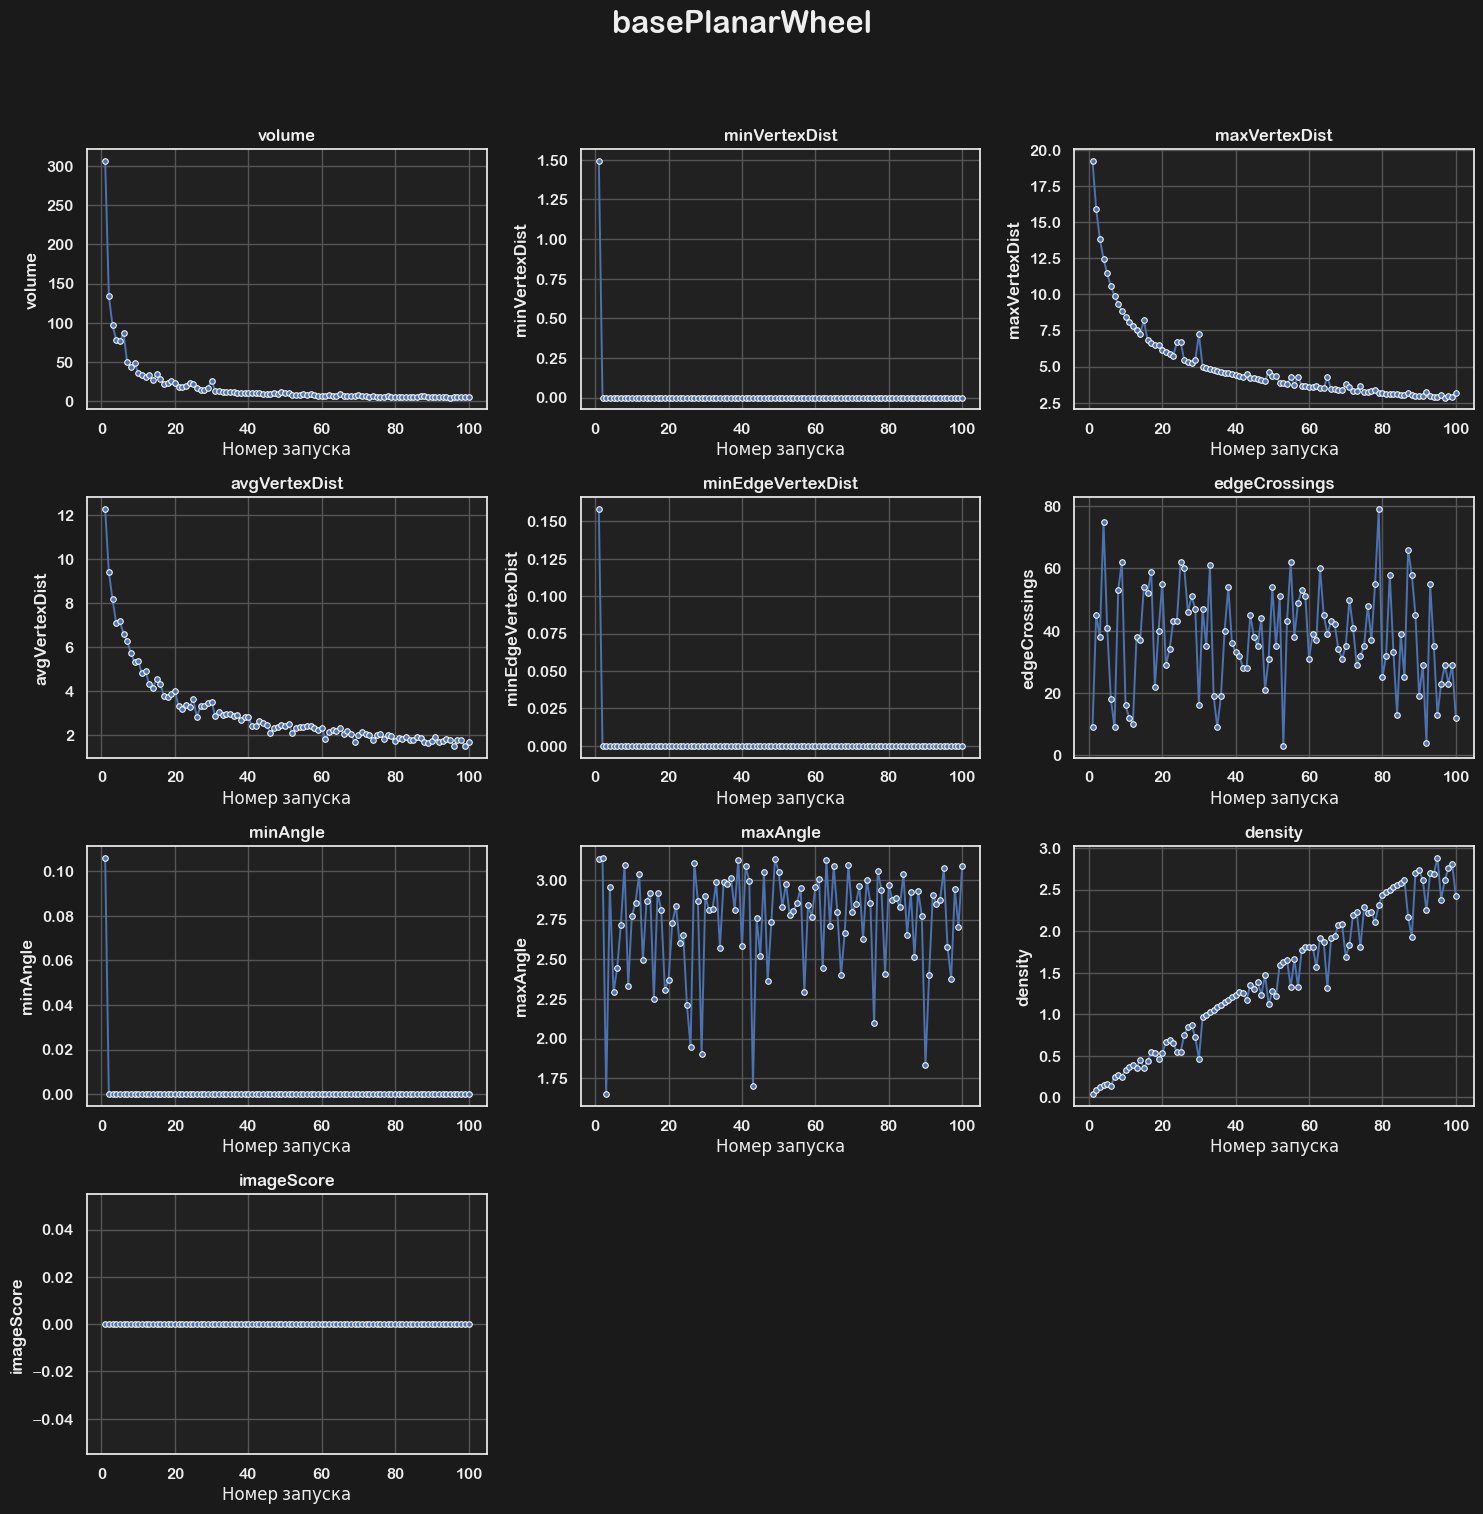

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


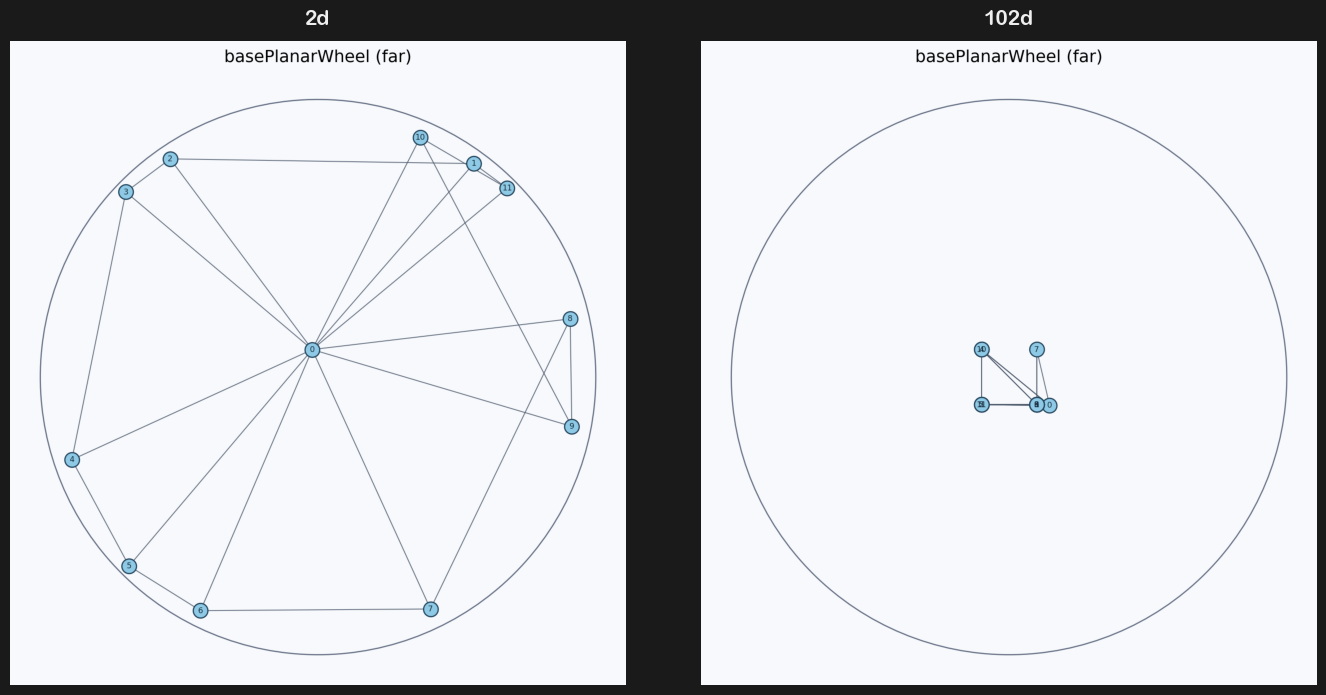

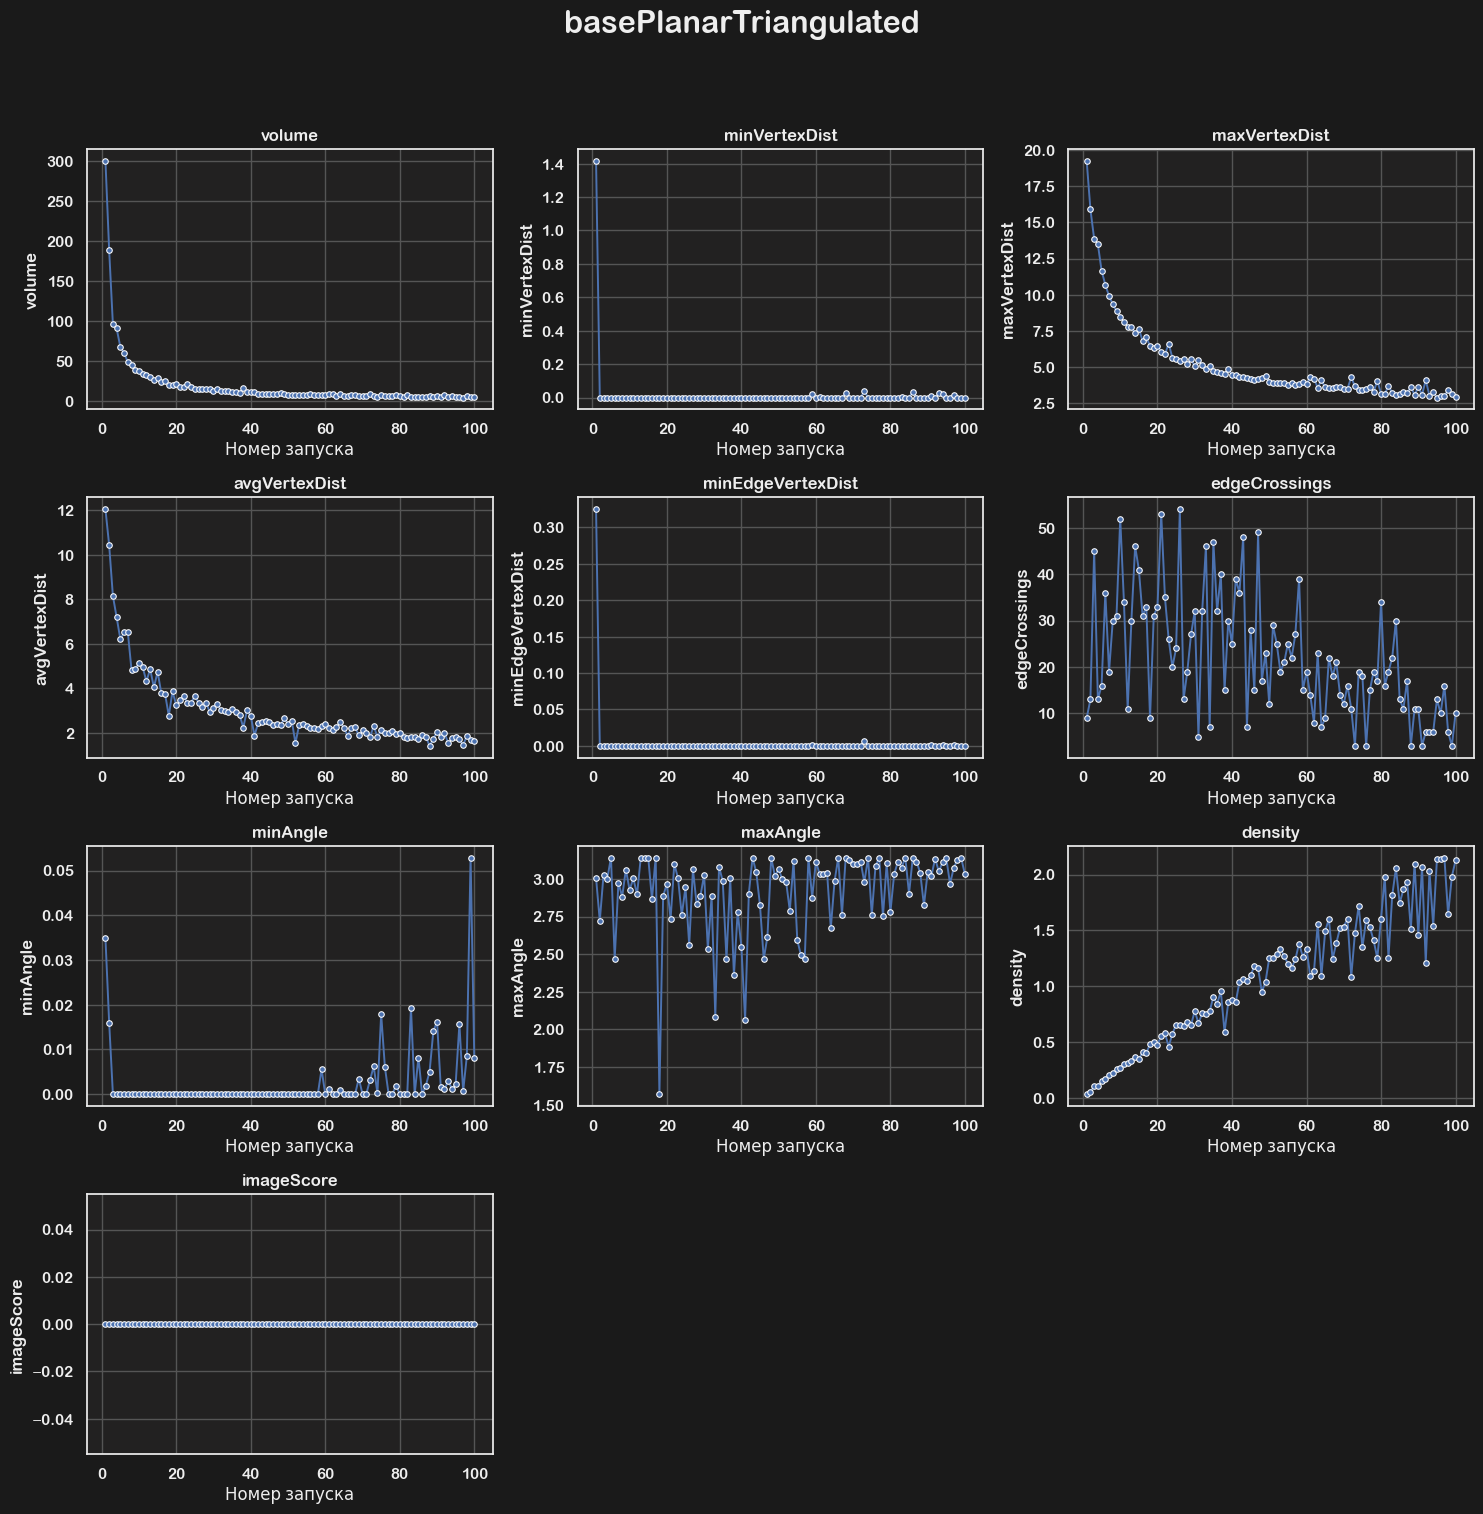

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


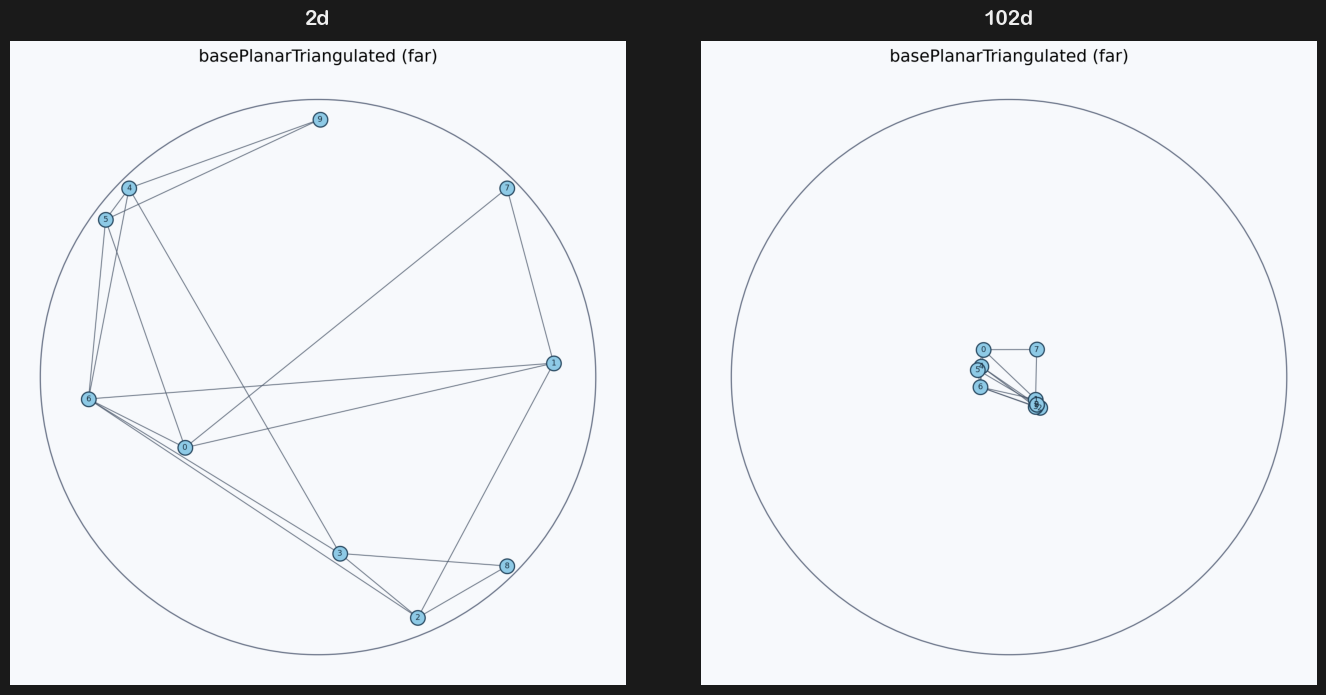

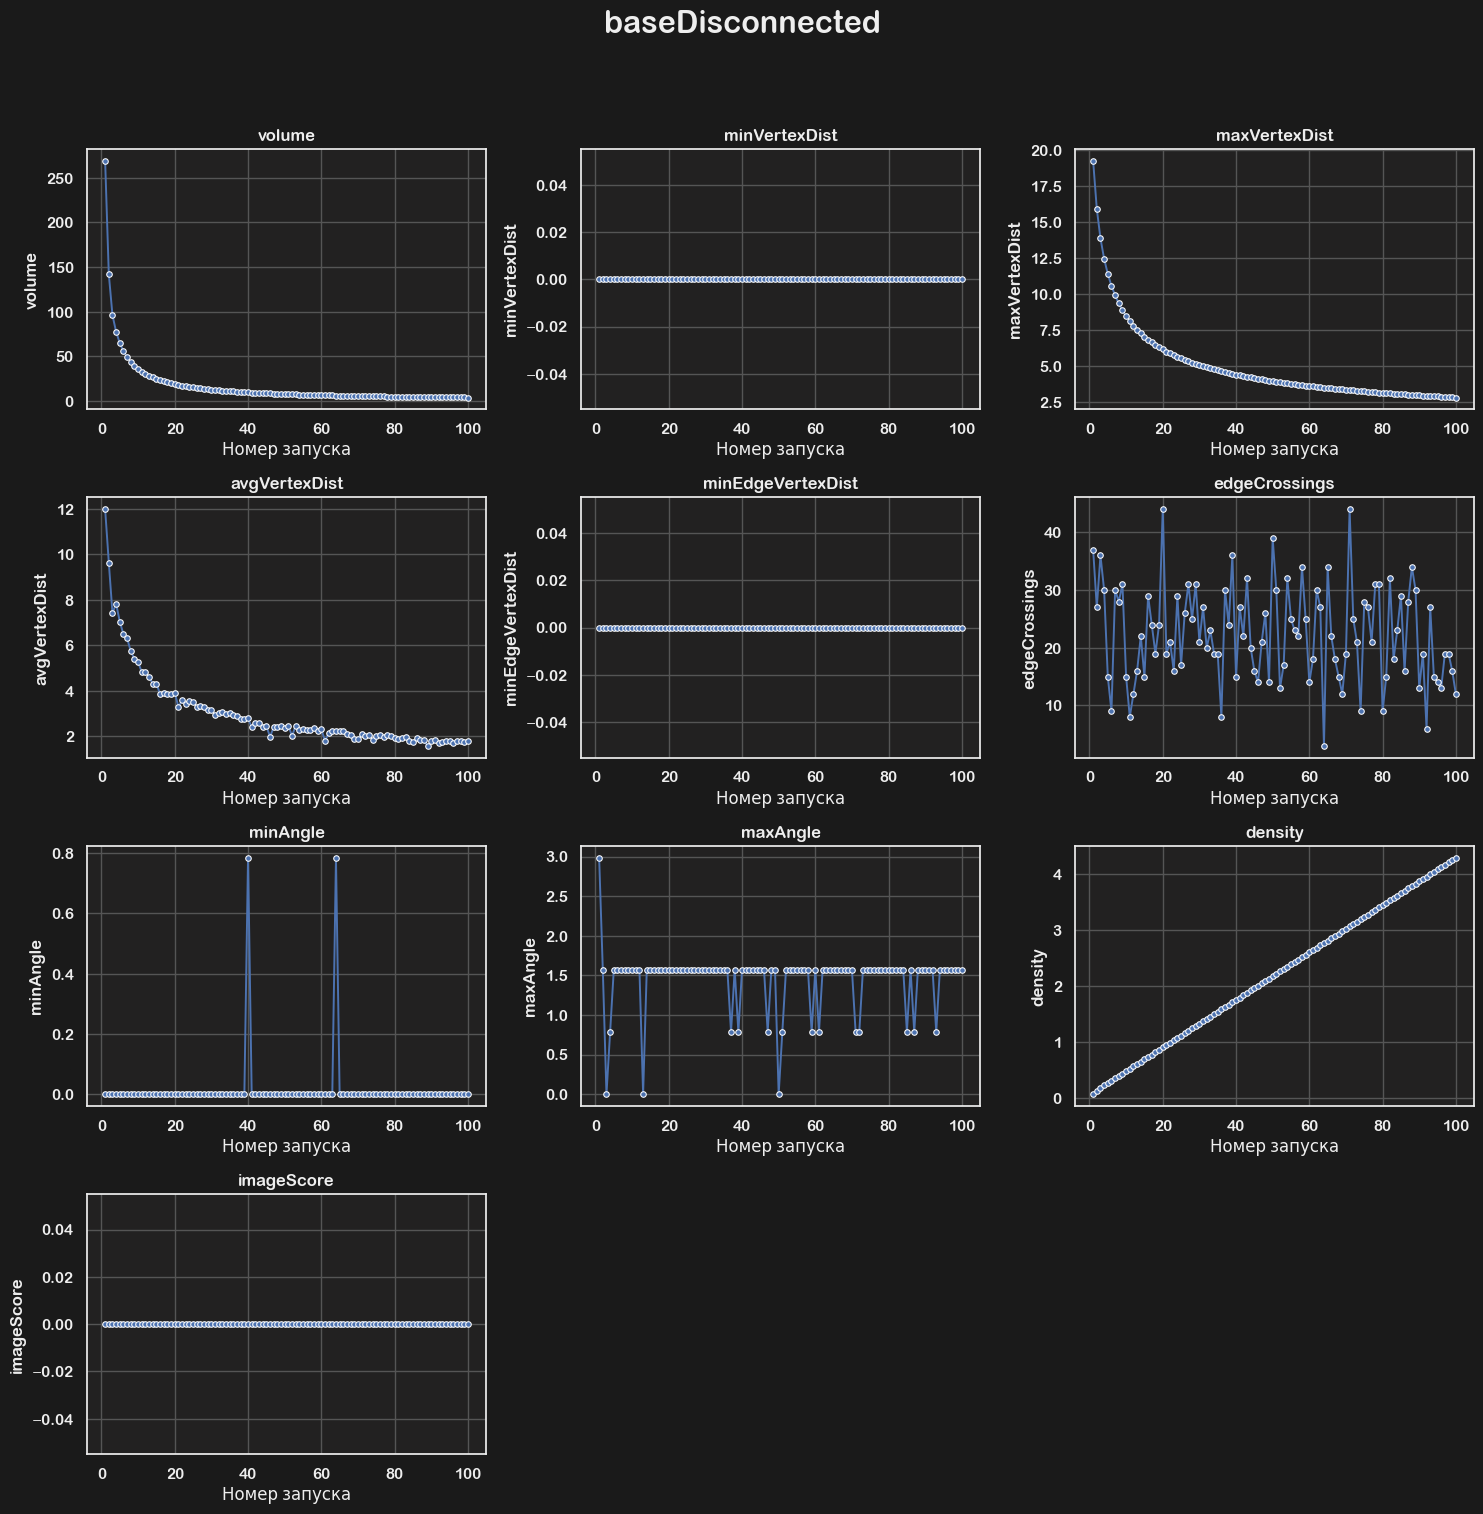

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


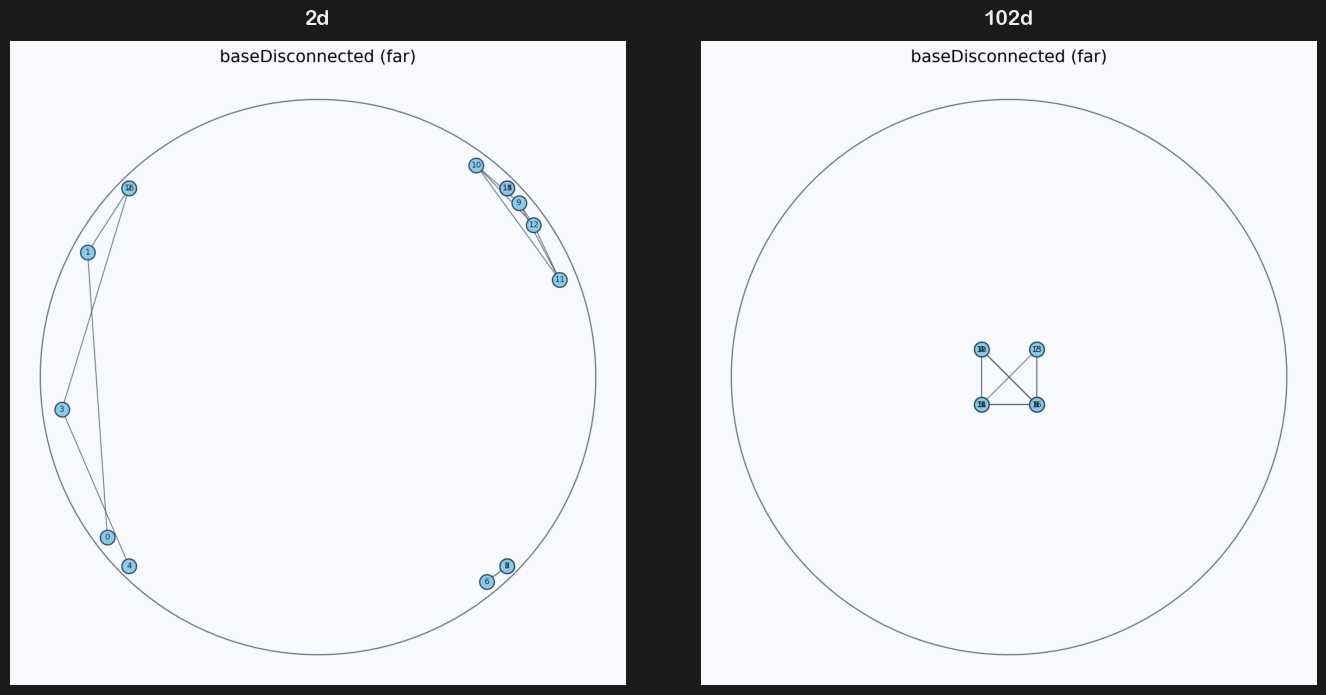

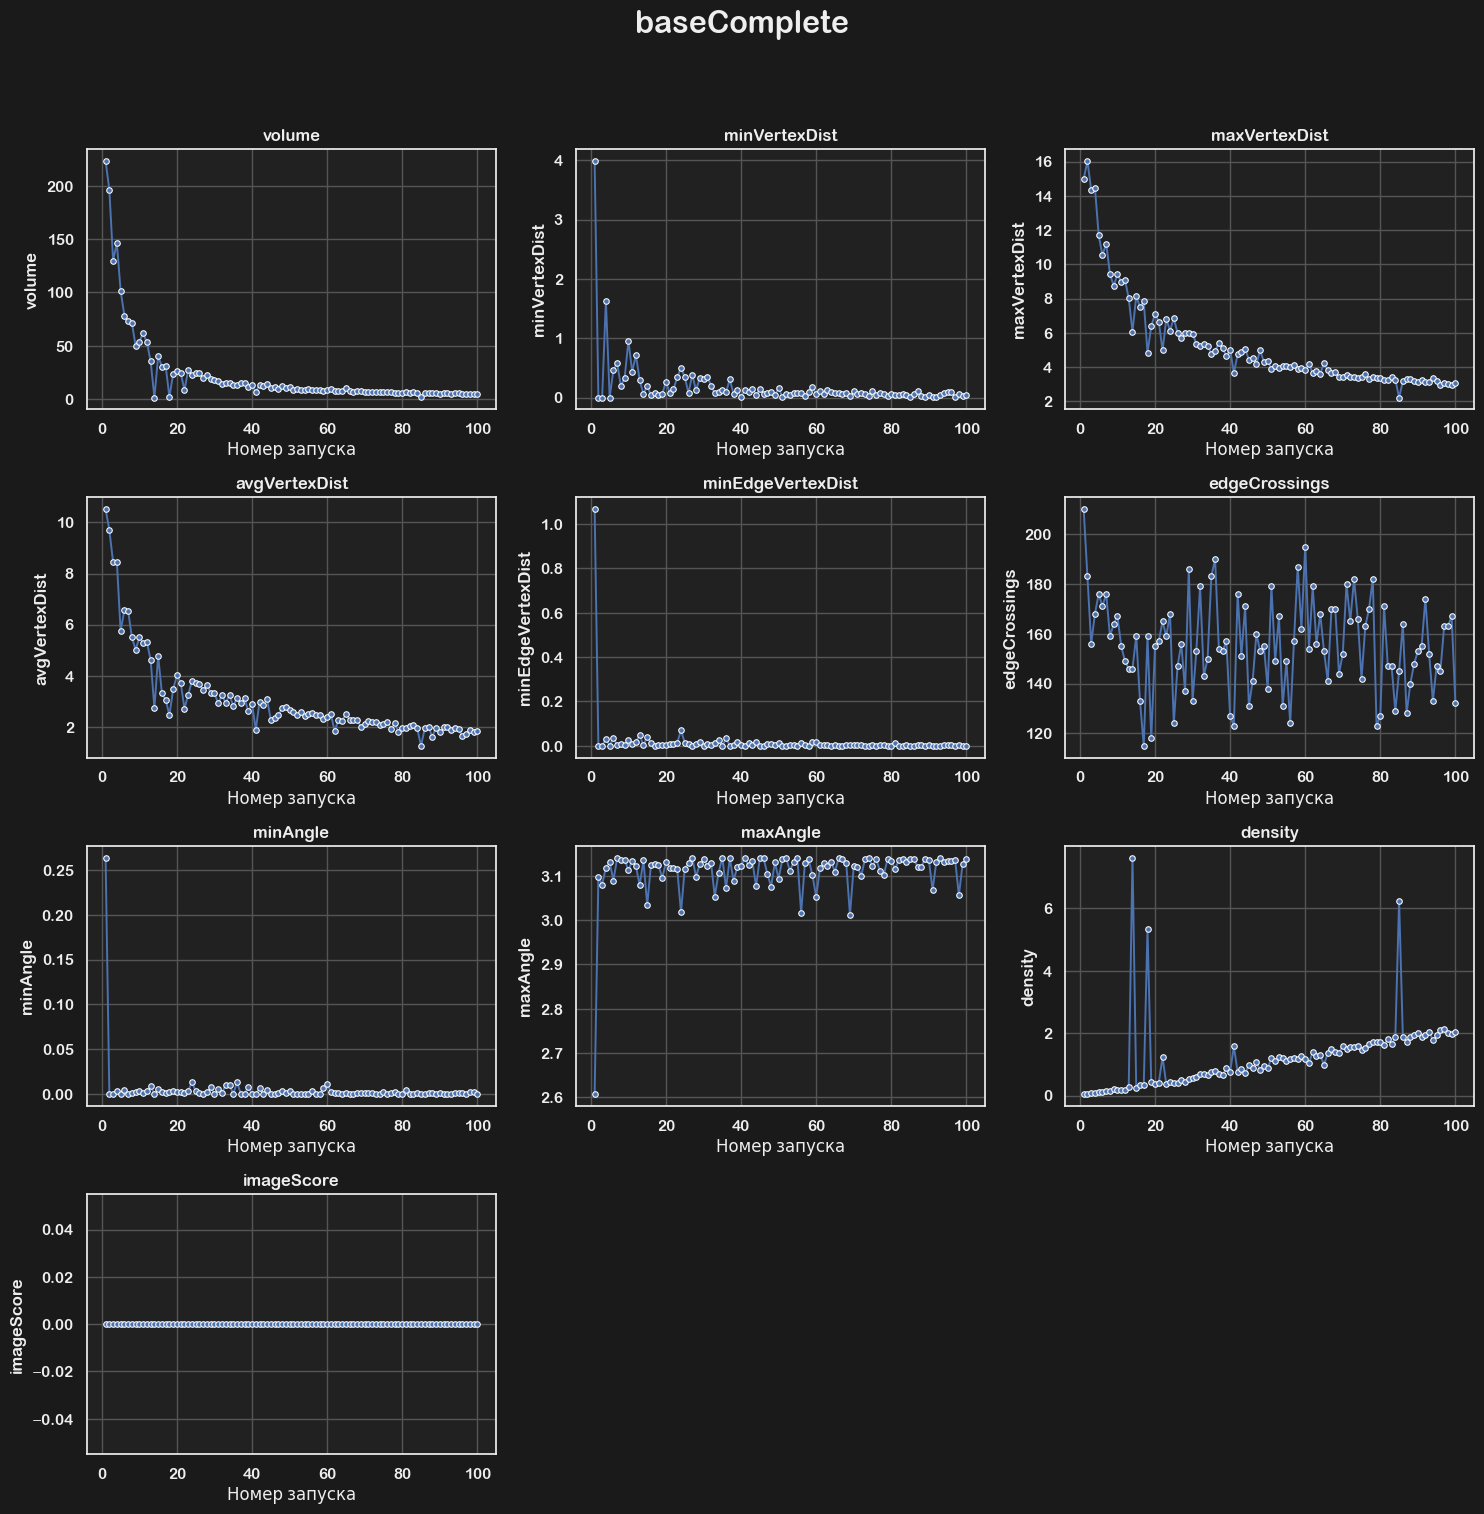

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


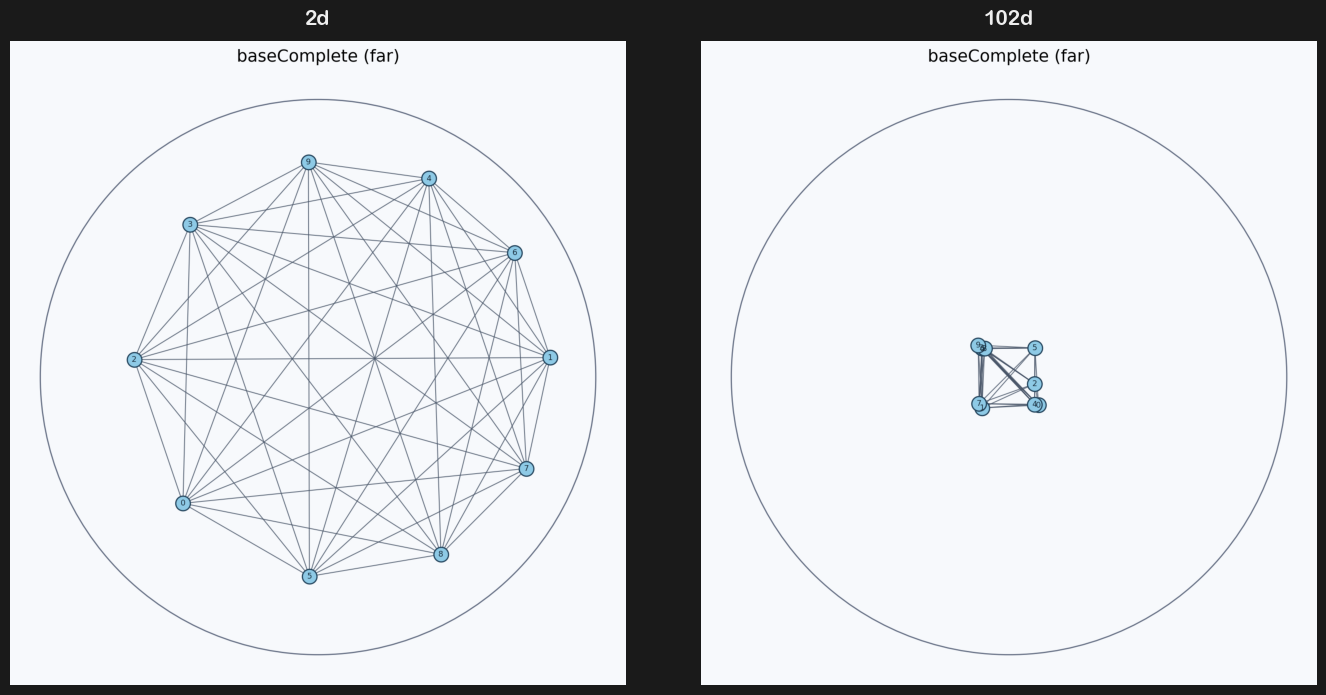

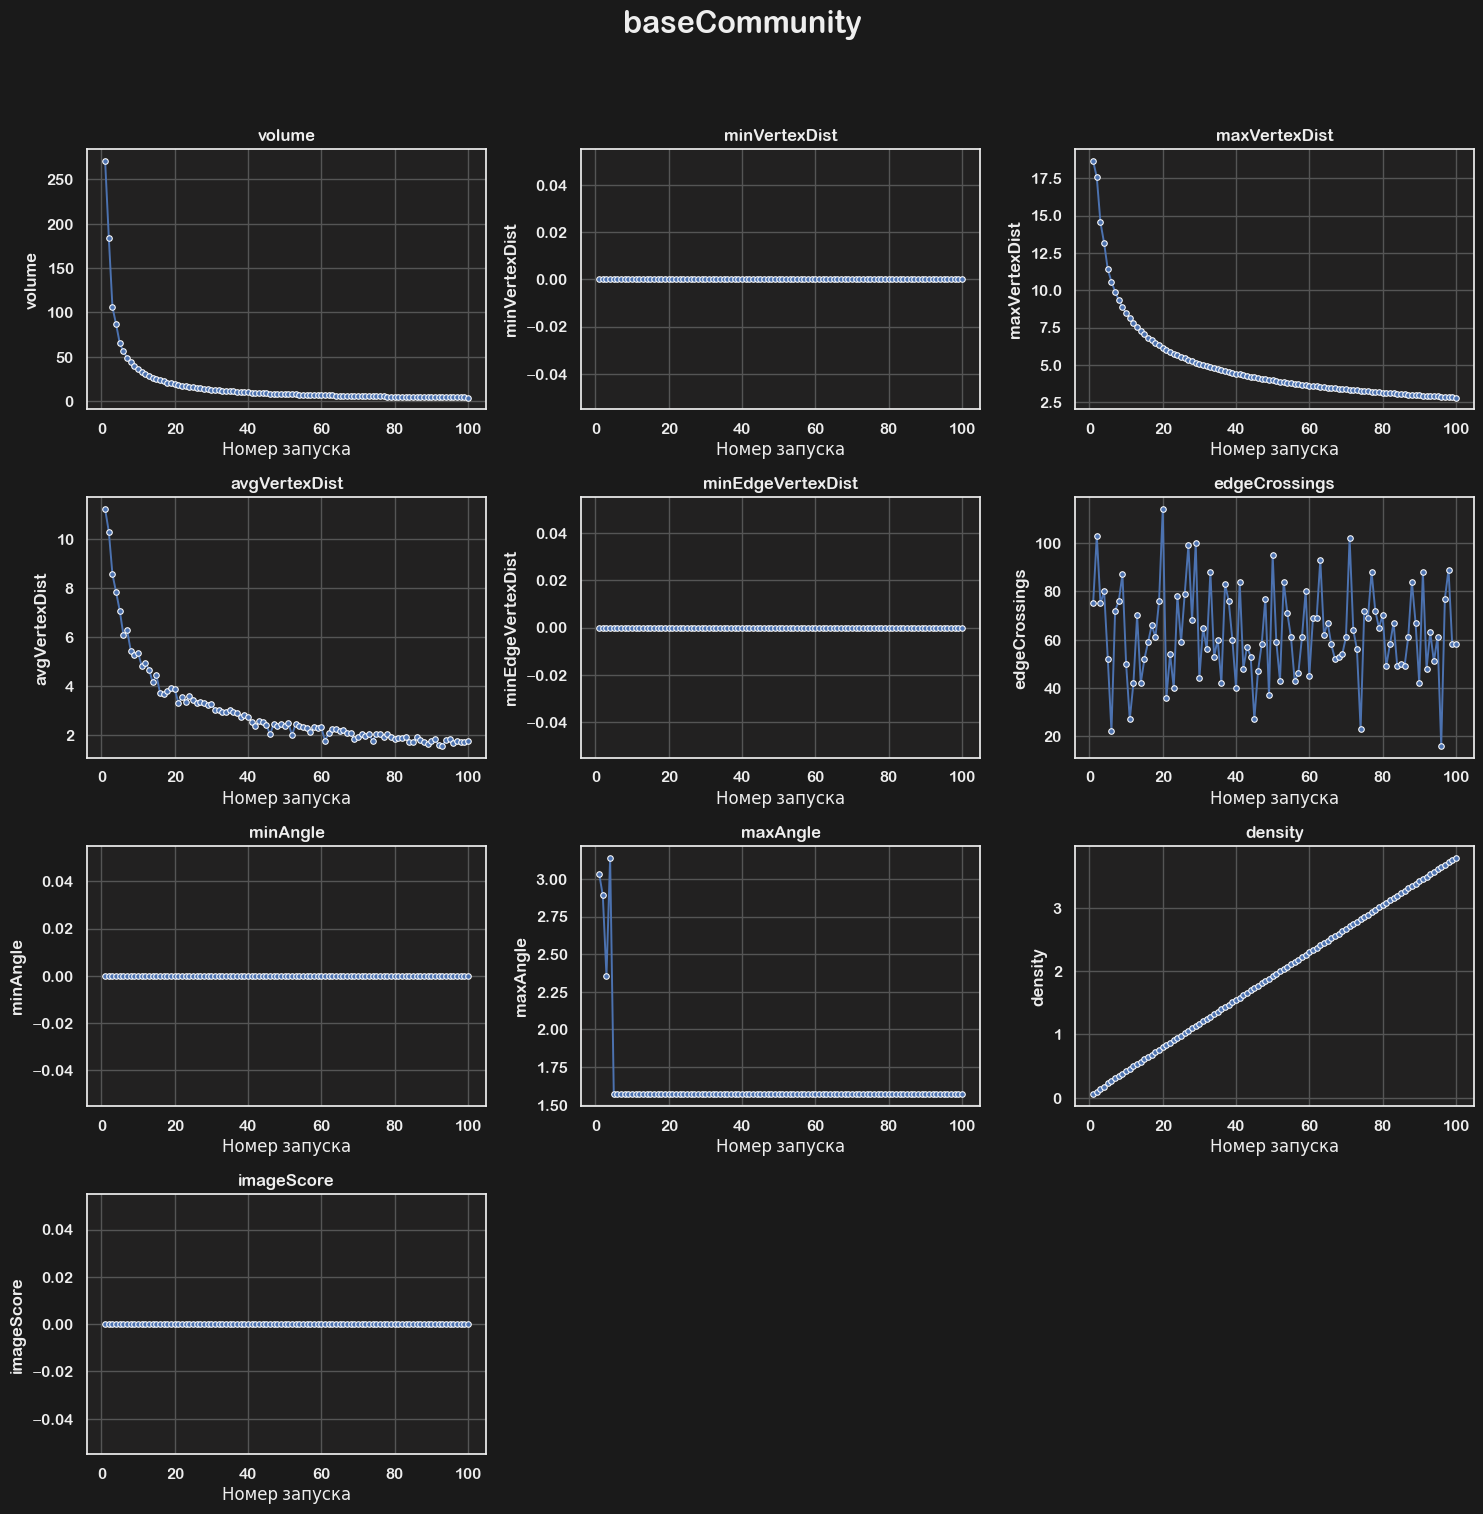

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_99.png


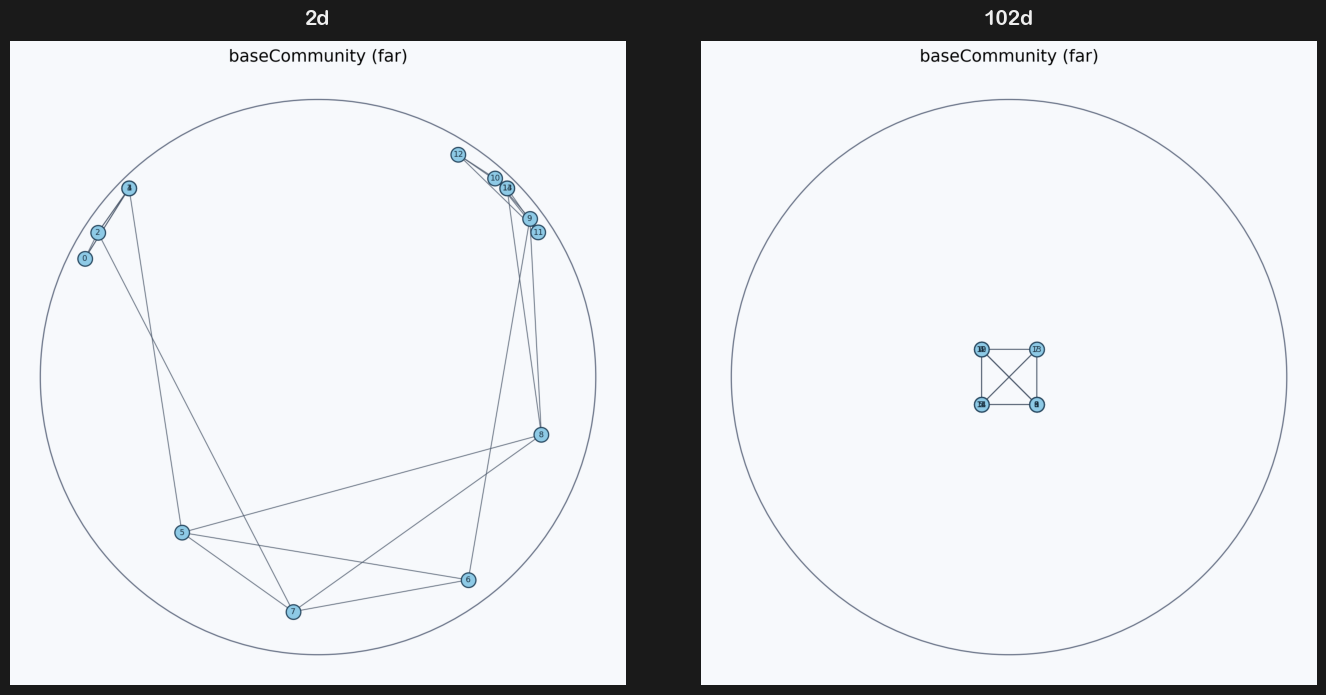

In [38]:
flags = [
    "--graph",
	"",
	"--algo",
	"far",
    "--initial-placement",
    "random",
    "--space",
    "hyperbolic",
    "--dim",
    "2",
    "--borderPolicy",
    "poly",
    "--projection",
    "kleinOrthogonal",
    "--2d",
    "--FS",
    "20, 20",
    "--dataset",
    "samples/baseDataset.json",
	"--output",
	"out/notebook/far/metrixFromDim/graph.json",
    "--seed",
    "1543",
]

algoFlags = [
    "--C",
    "1.0",
    "--I",
    "100",
]

borderFlags = [
    "--S",
    "",
]

def flagsForRun(iters):
    for ind in iters:
        flags[9] = f"{ind + 2}"
        yield flags

def borderFlagsForRun(iters):
    for ind in iters:
        borderFlags[1] = ','.join(["5" for _ in range(ind + 2)])
        yield borderFlags

for gName in graphs:
    flags[1] = gName
    res = runTests(mainPath, flags=flags, n=100, flagsForRun=flagsForRun, algoFlags=algoFlags, borderFlags=borderFlags, borderFlagsForRun=borderFlagsForRun)
    plotMetrics(df=res, title=gName)
    p1 = renderRun(mainPath, res, 1)
    p2 = renderRun(mainPath, res, len(res))
    # print(res.columns)
    # print(res.head())
    displayTwo(p1, p2, title1="2d", title2="102d")
    
    


Теперь проекция будет реализована, как подбор оптимального угла для "камеры". То есть выбираются 1000 случайных камер и среди них выбирается лучшая по номрализованным метрикам. Так же будем идти до 62 мерного.

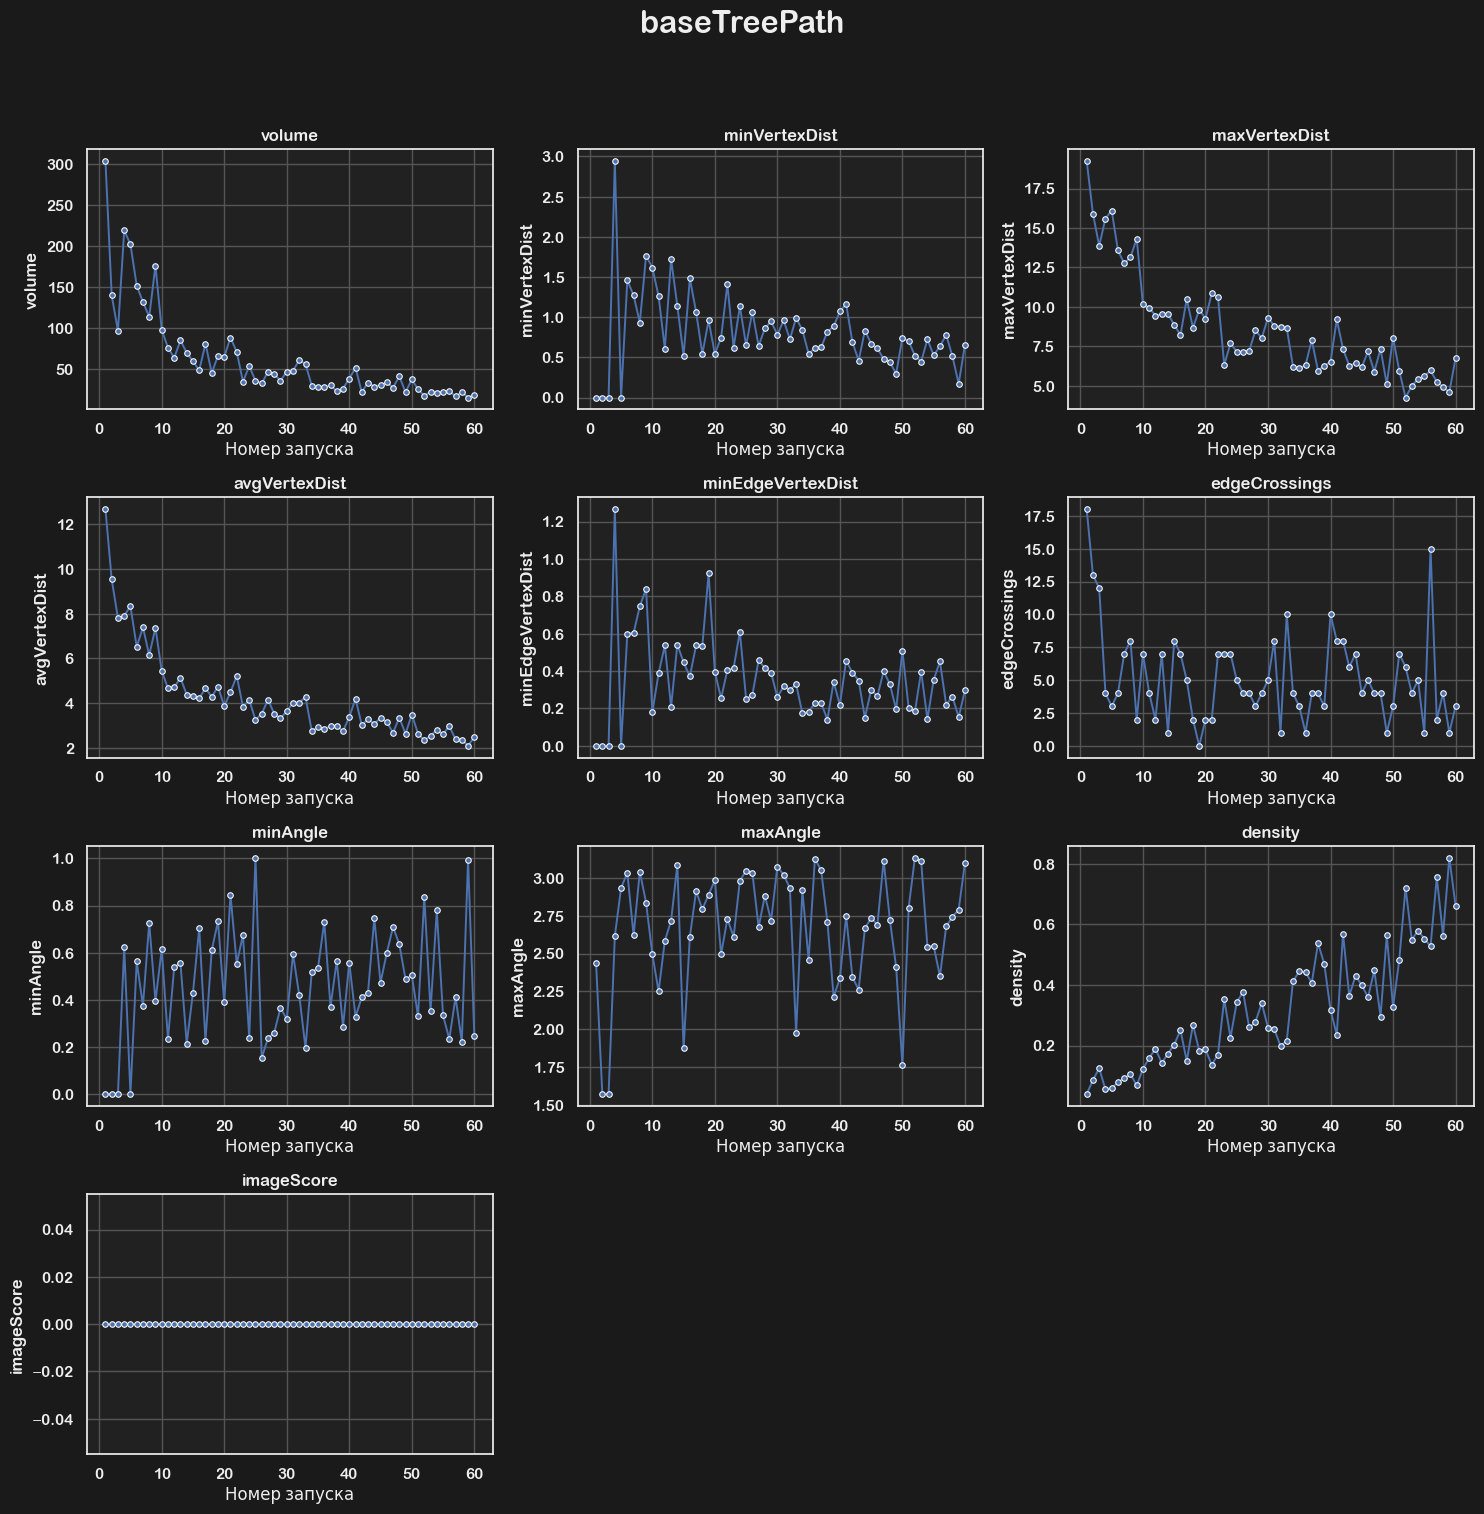

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


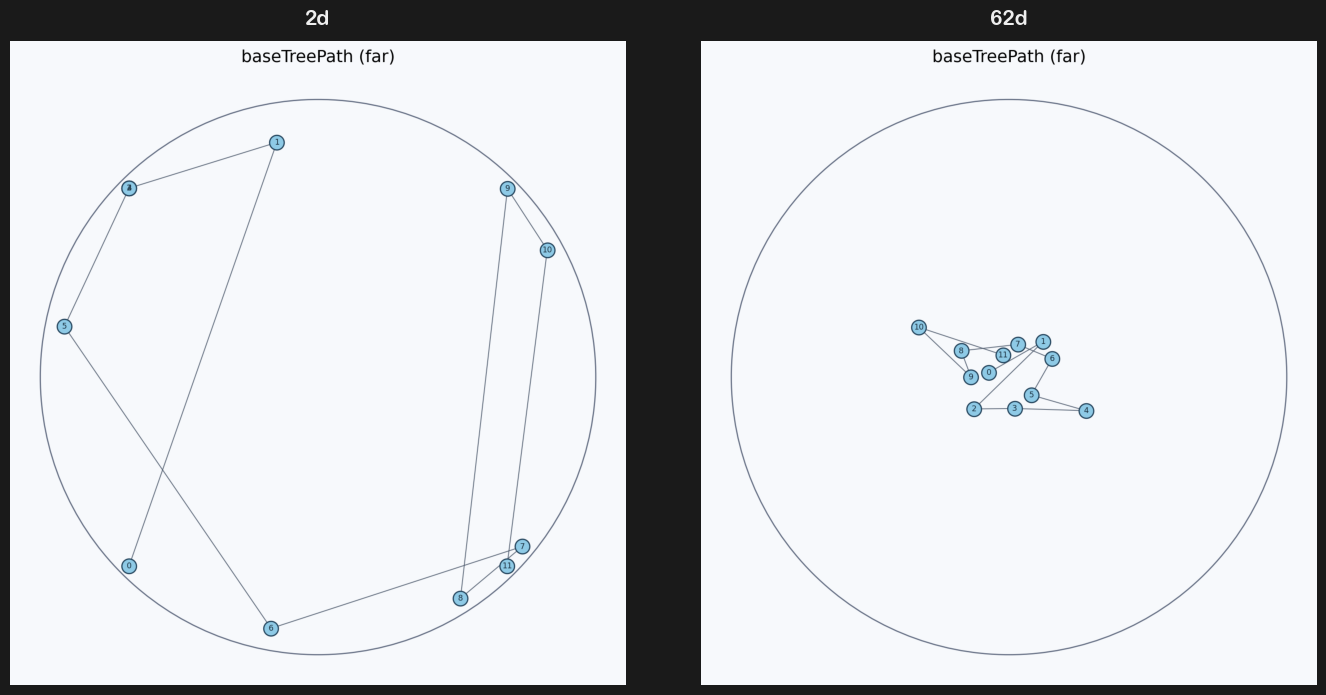

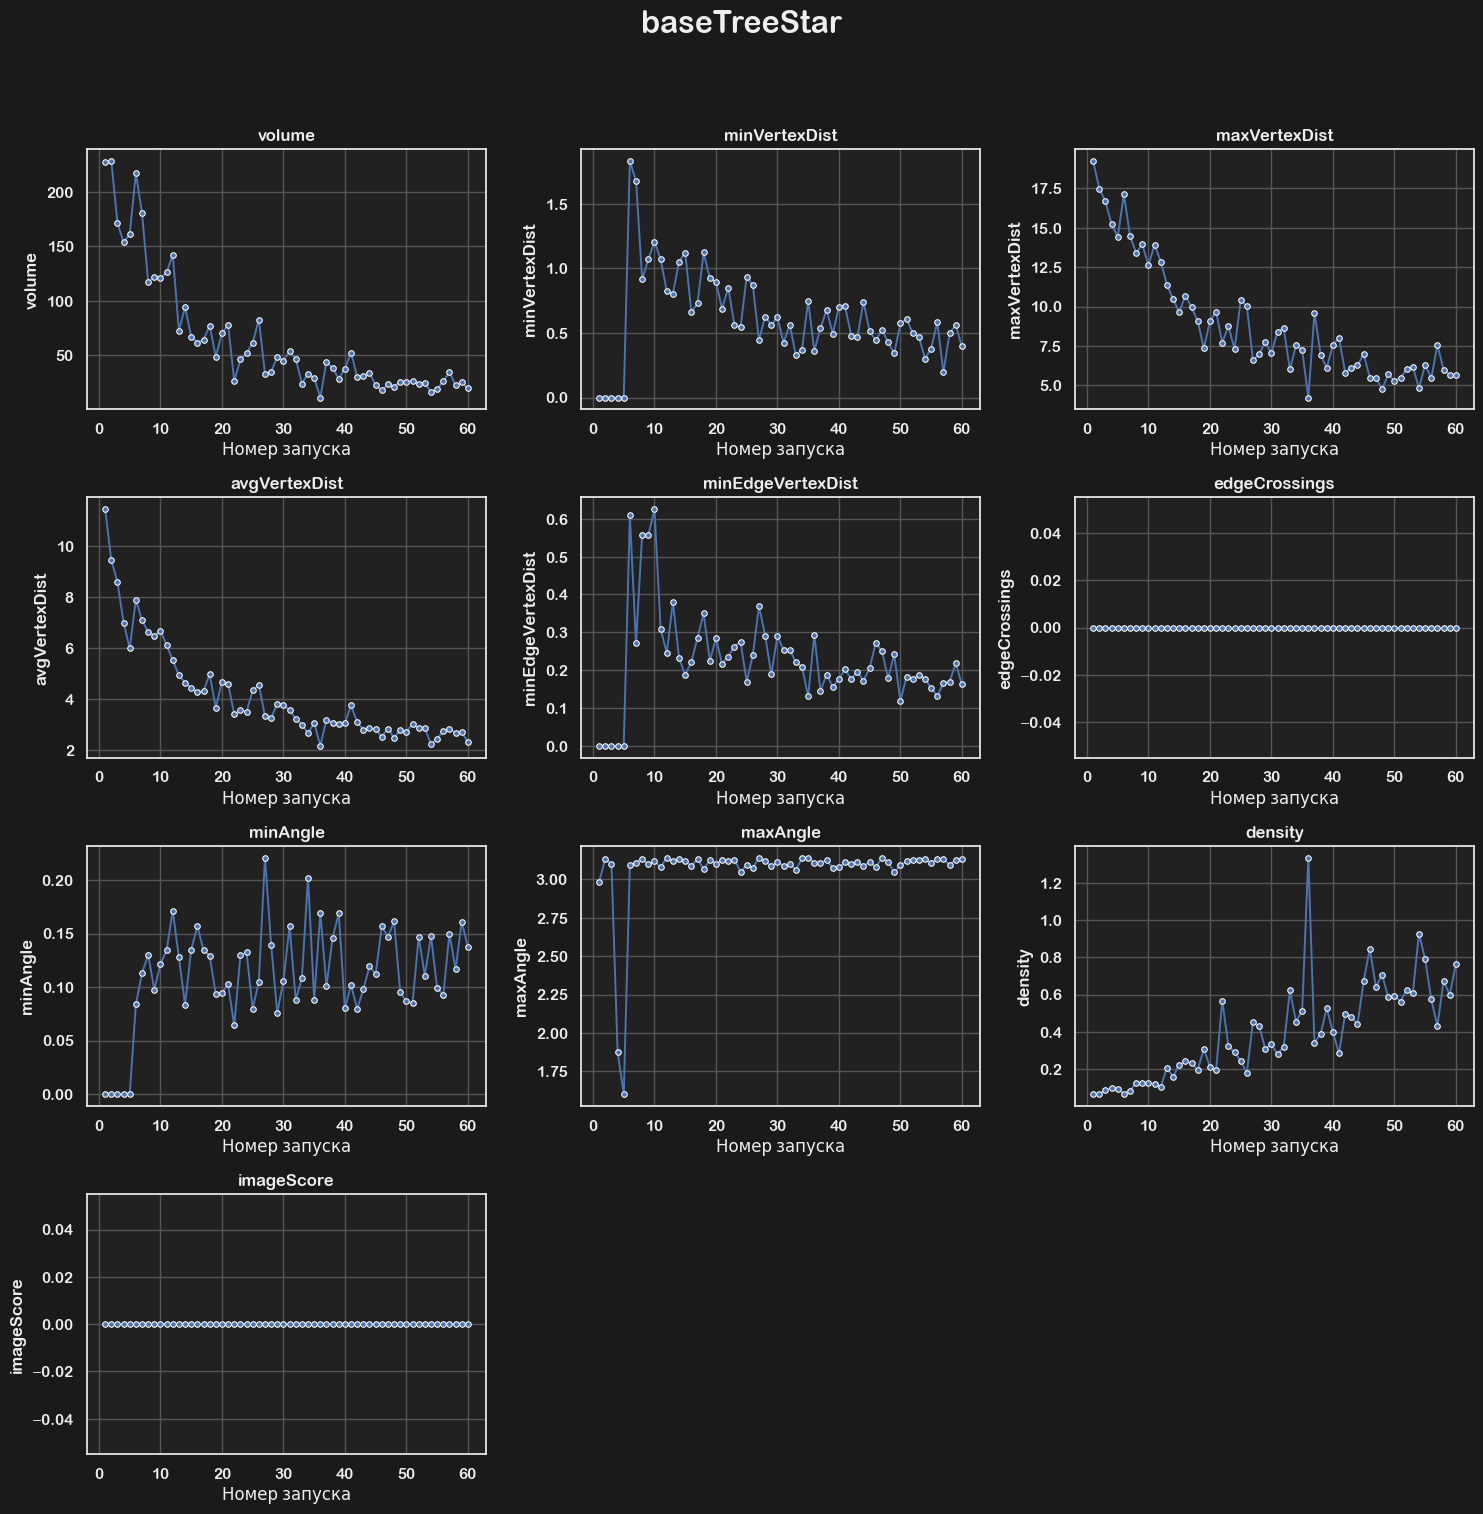

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


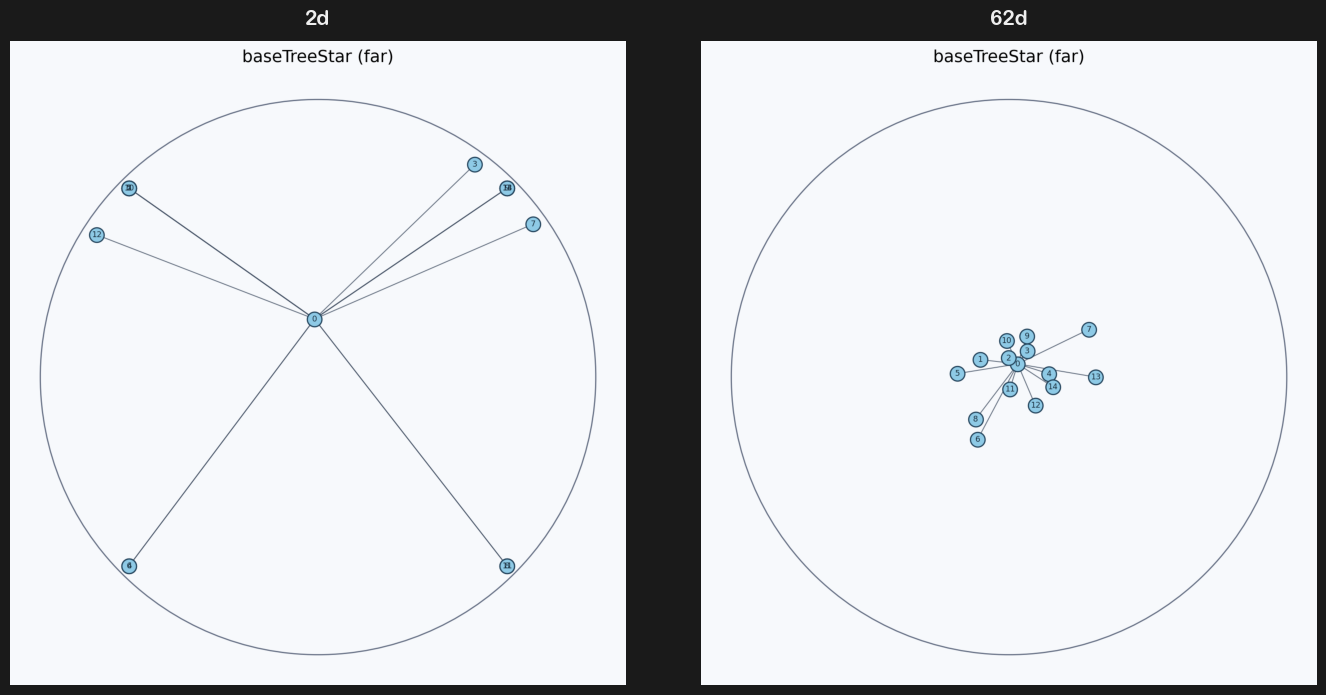

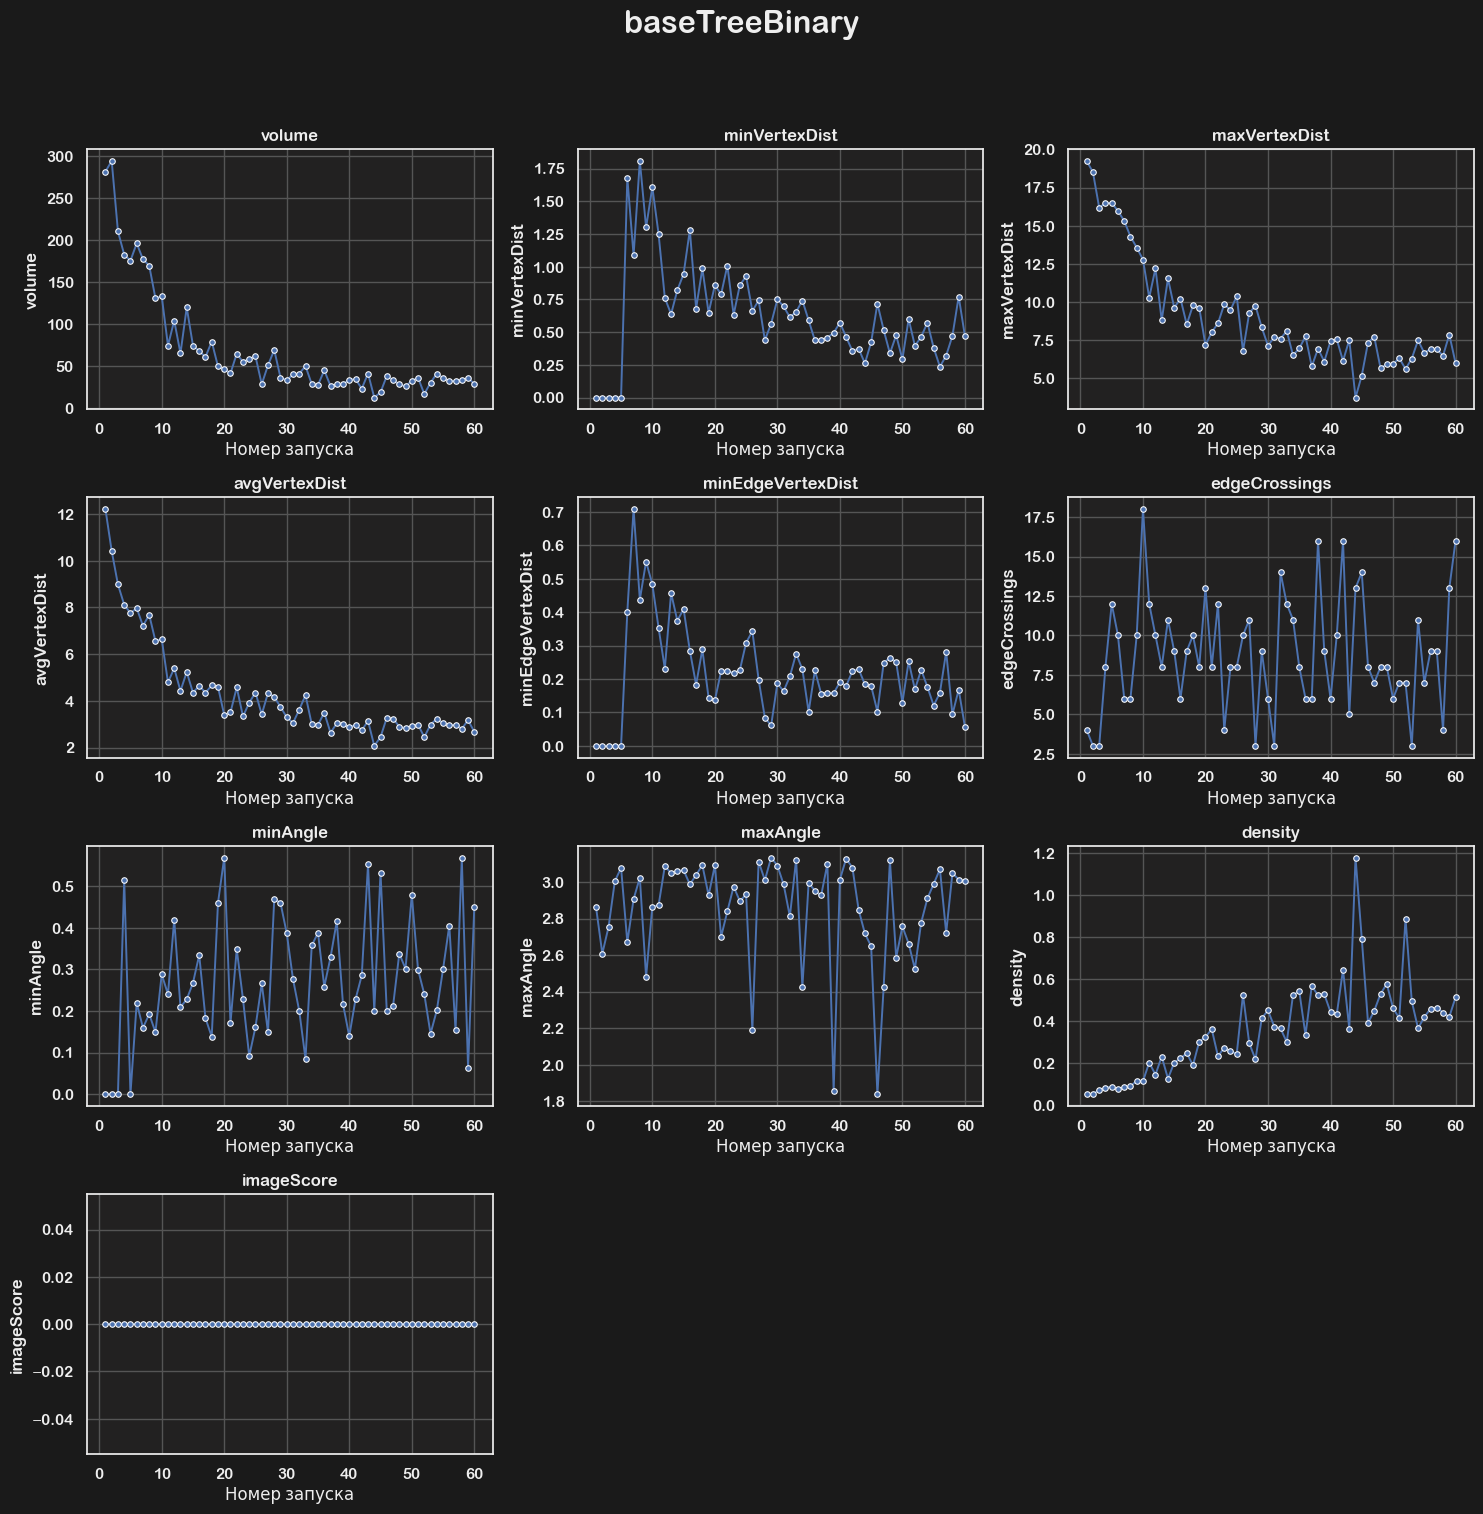

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


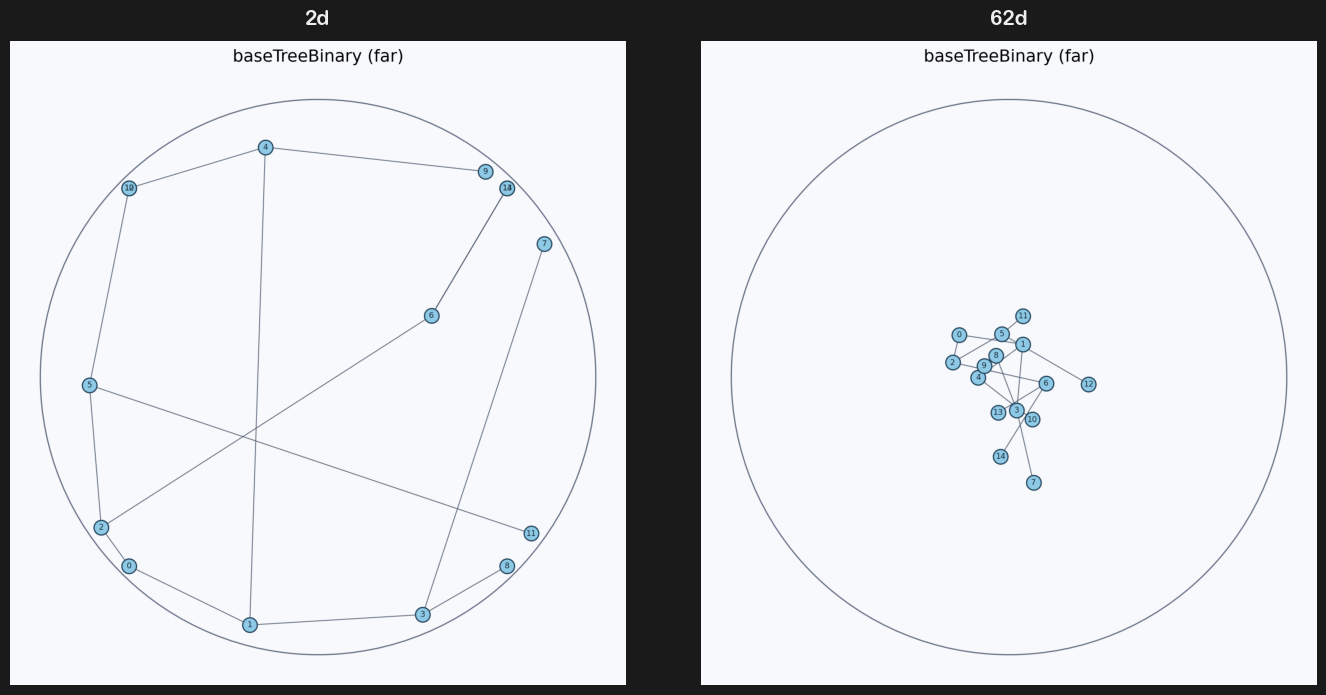

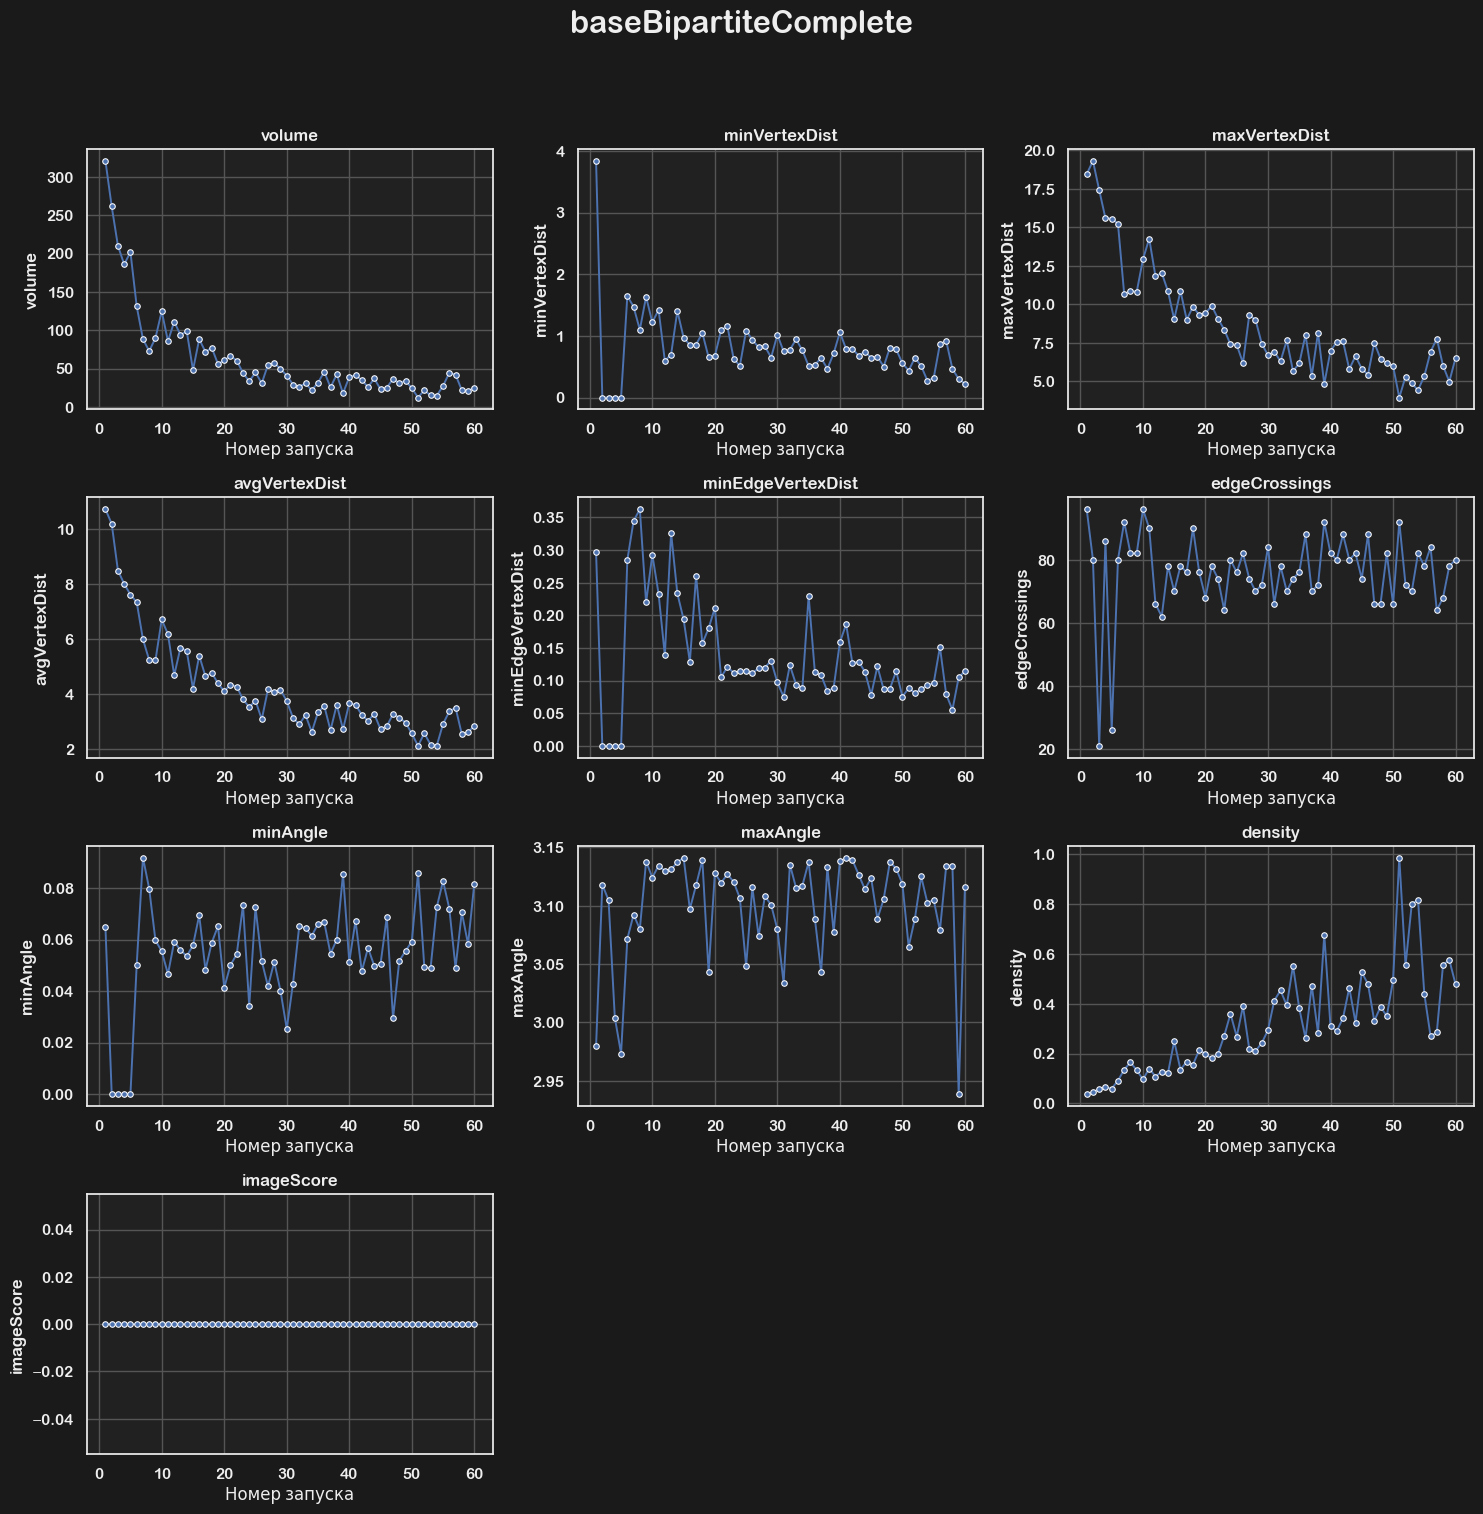

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


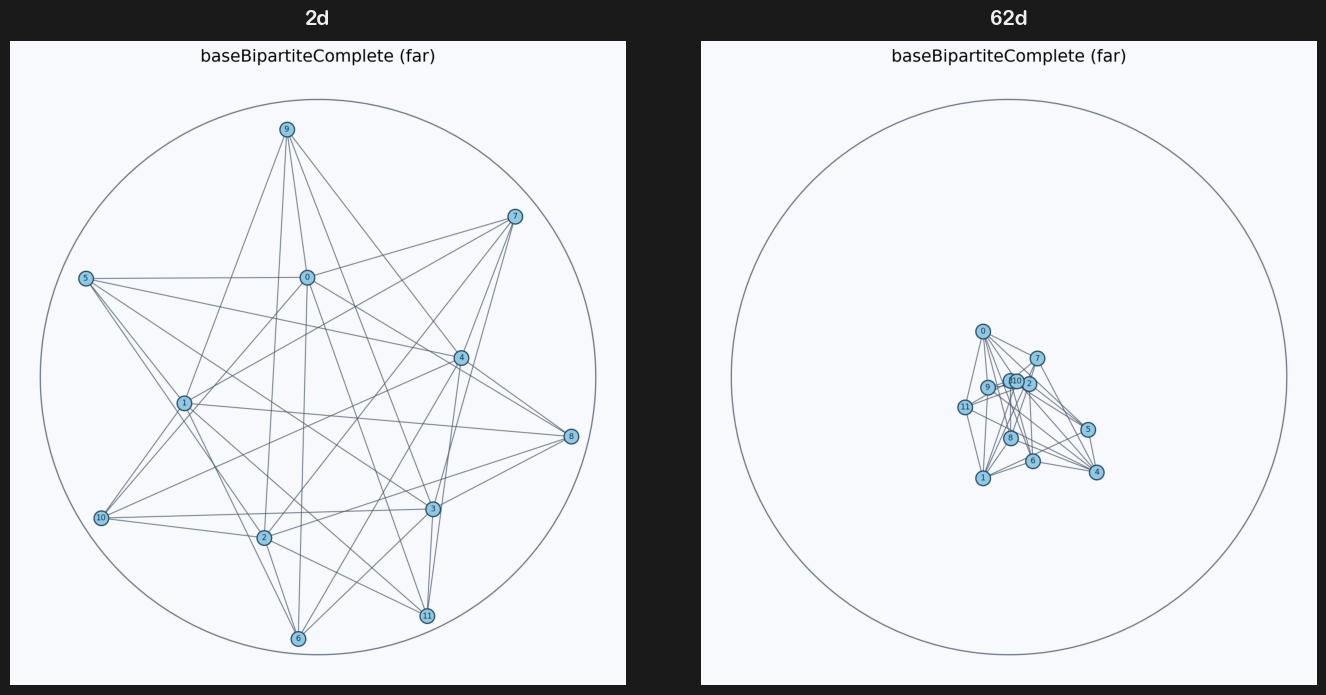

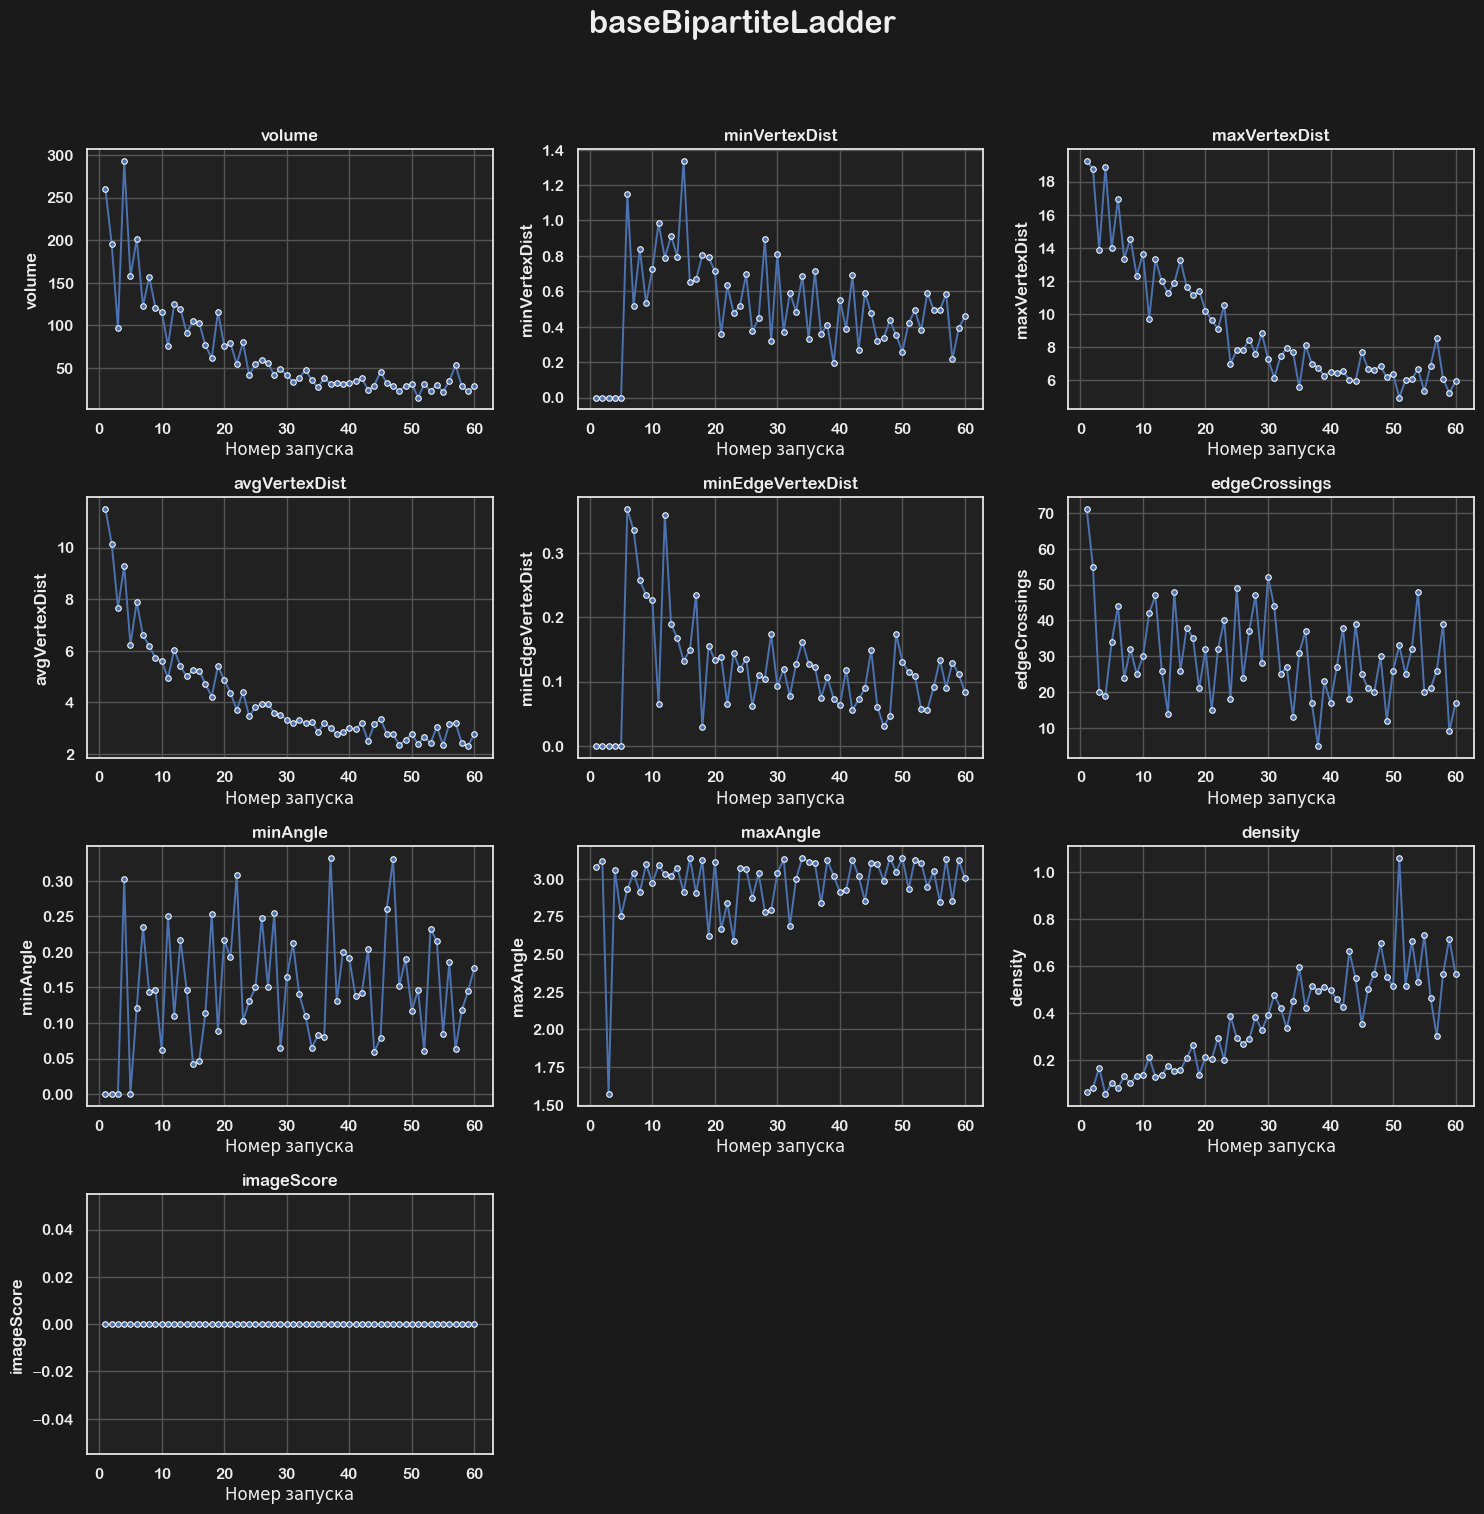

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


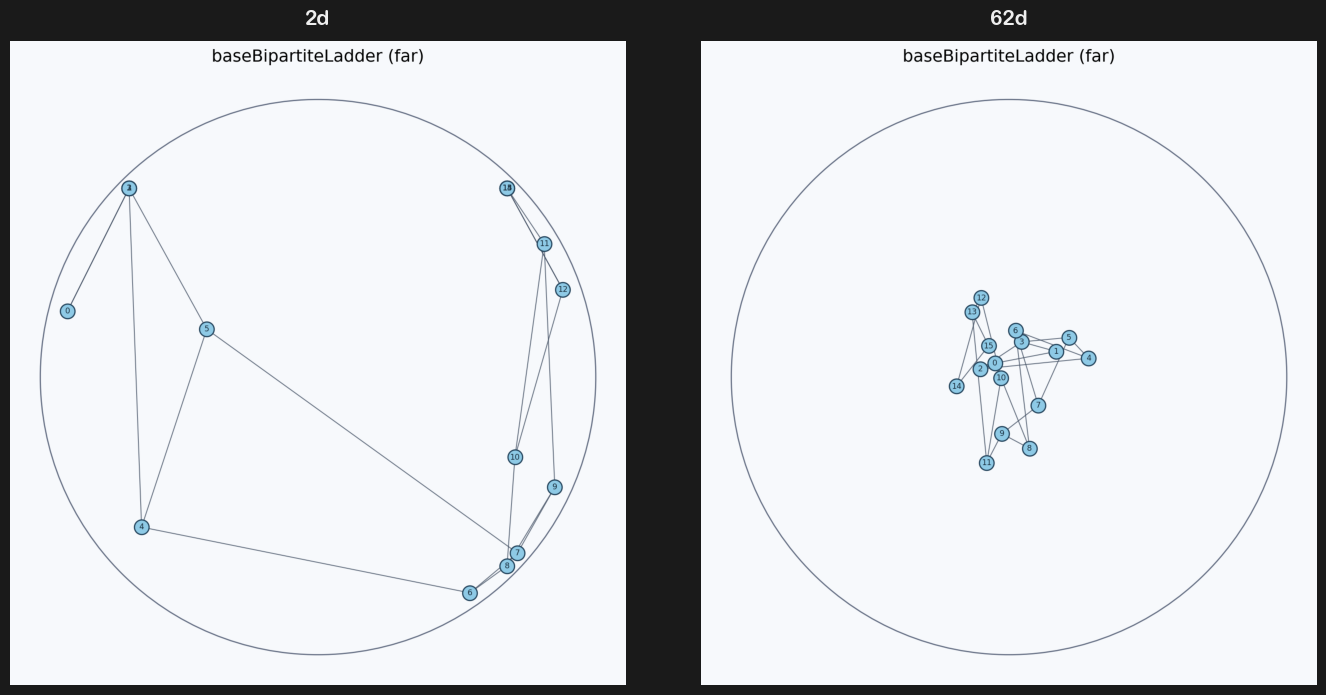

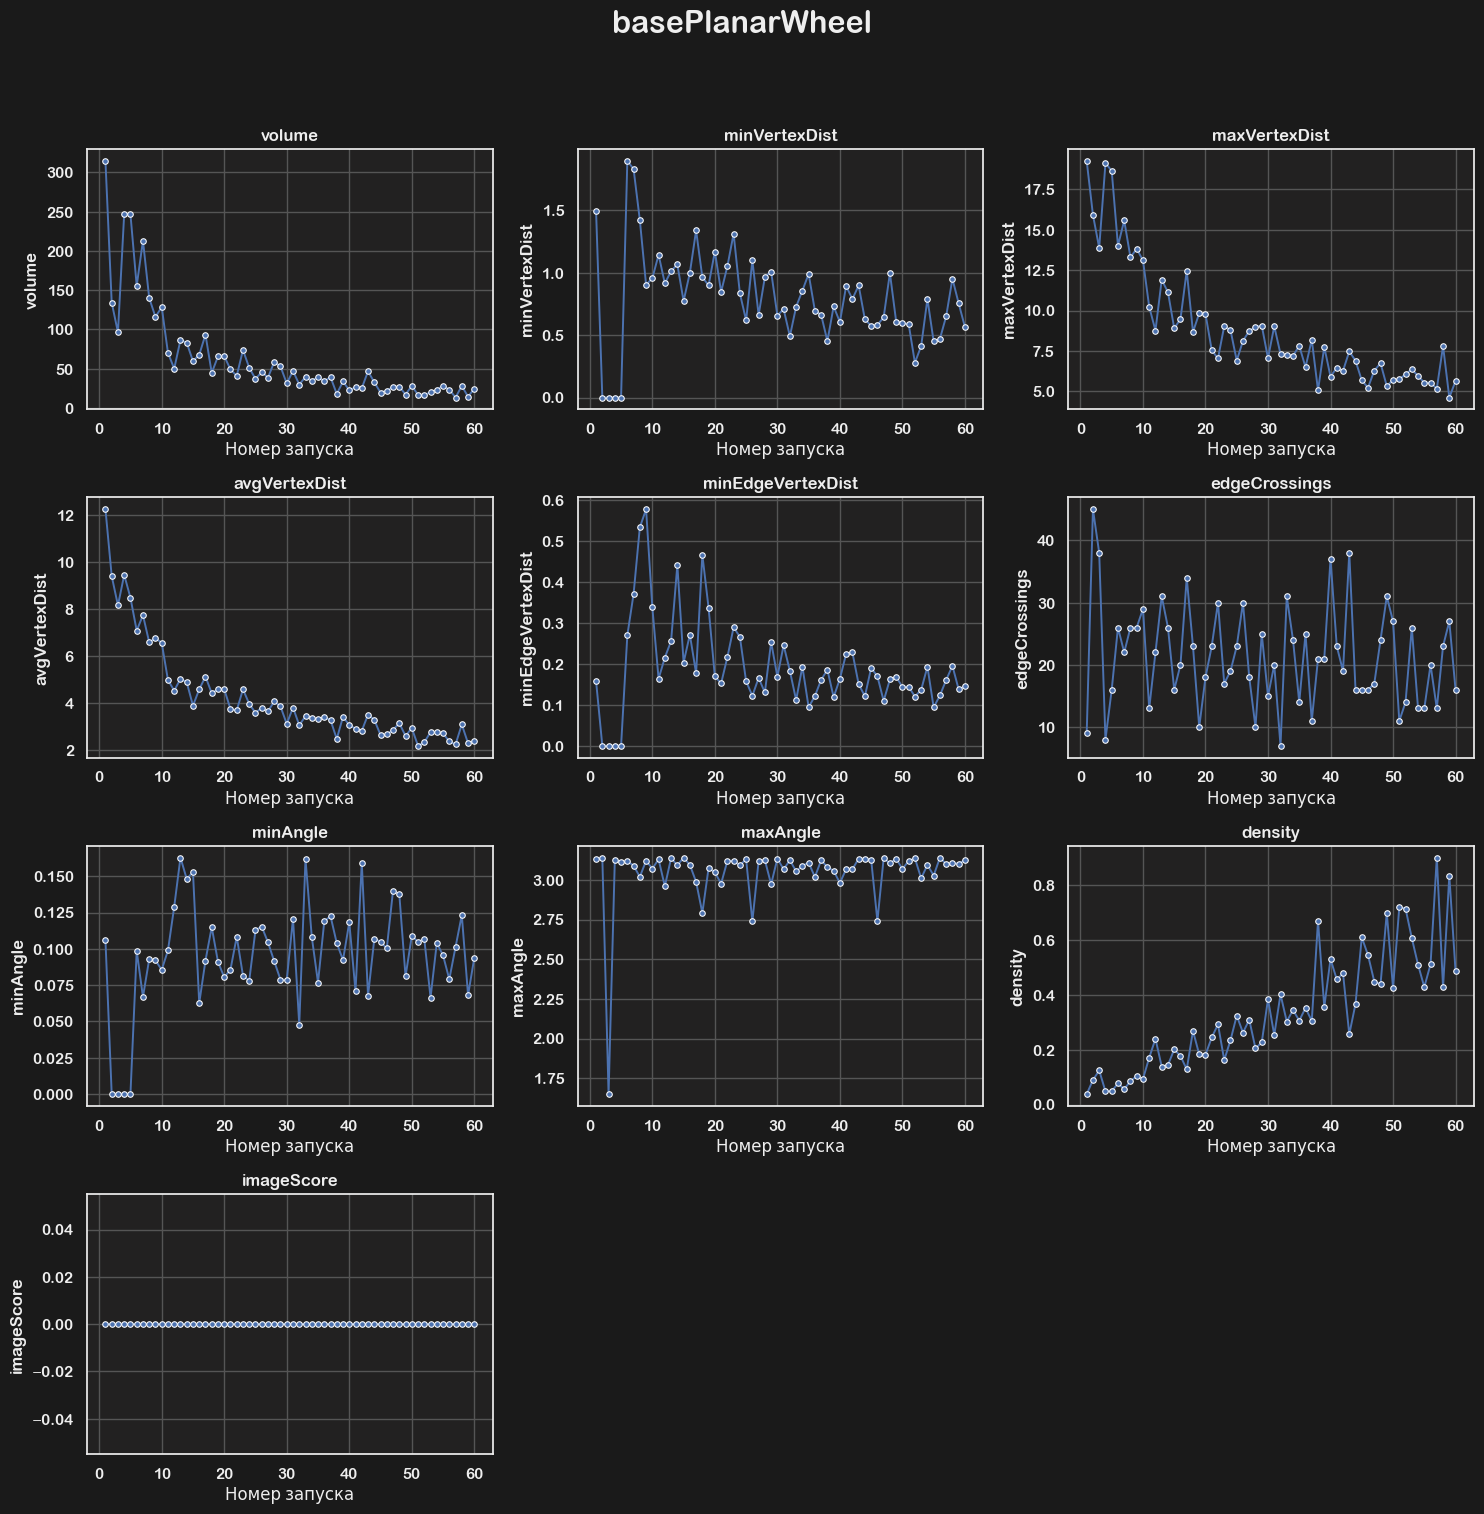

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


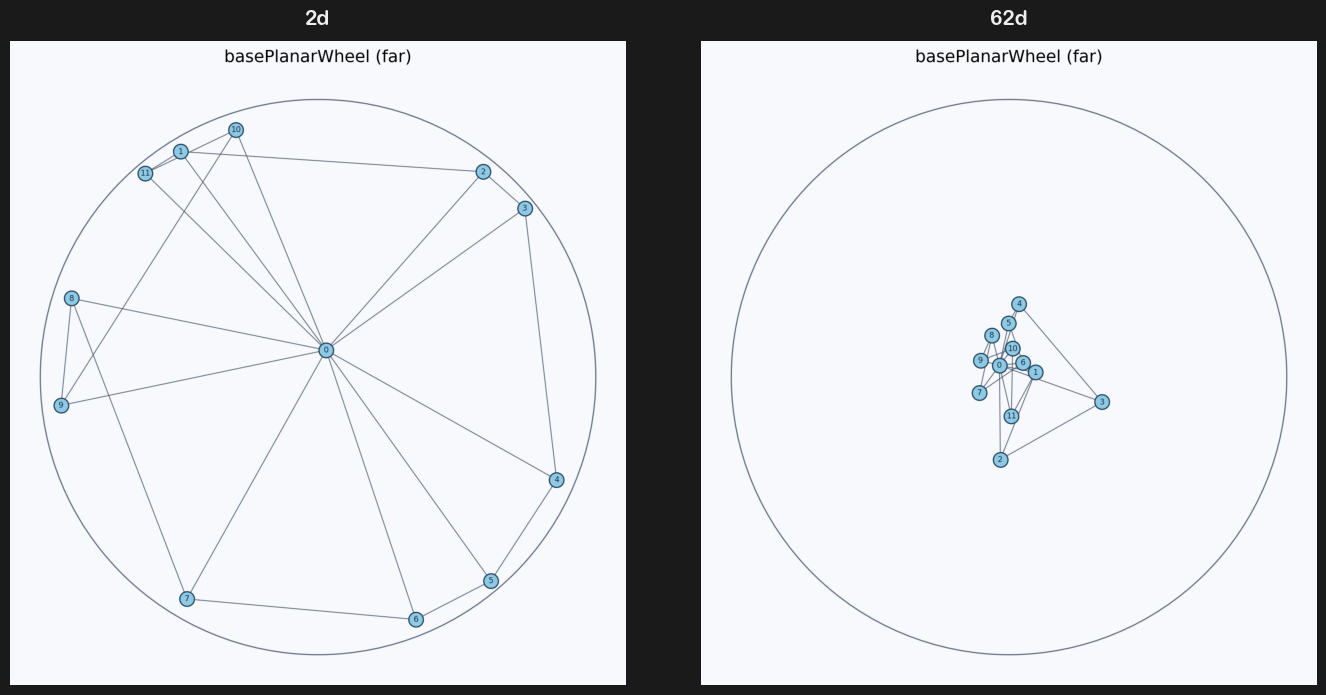

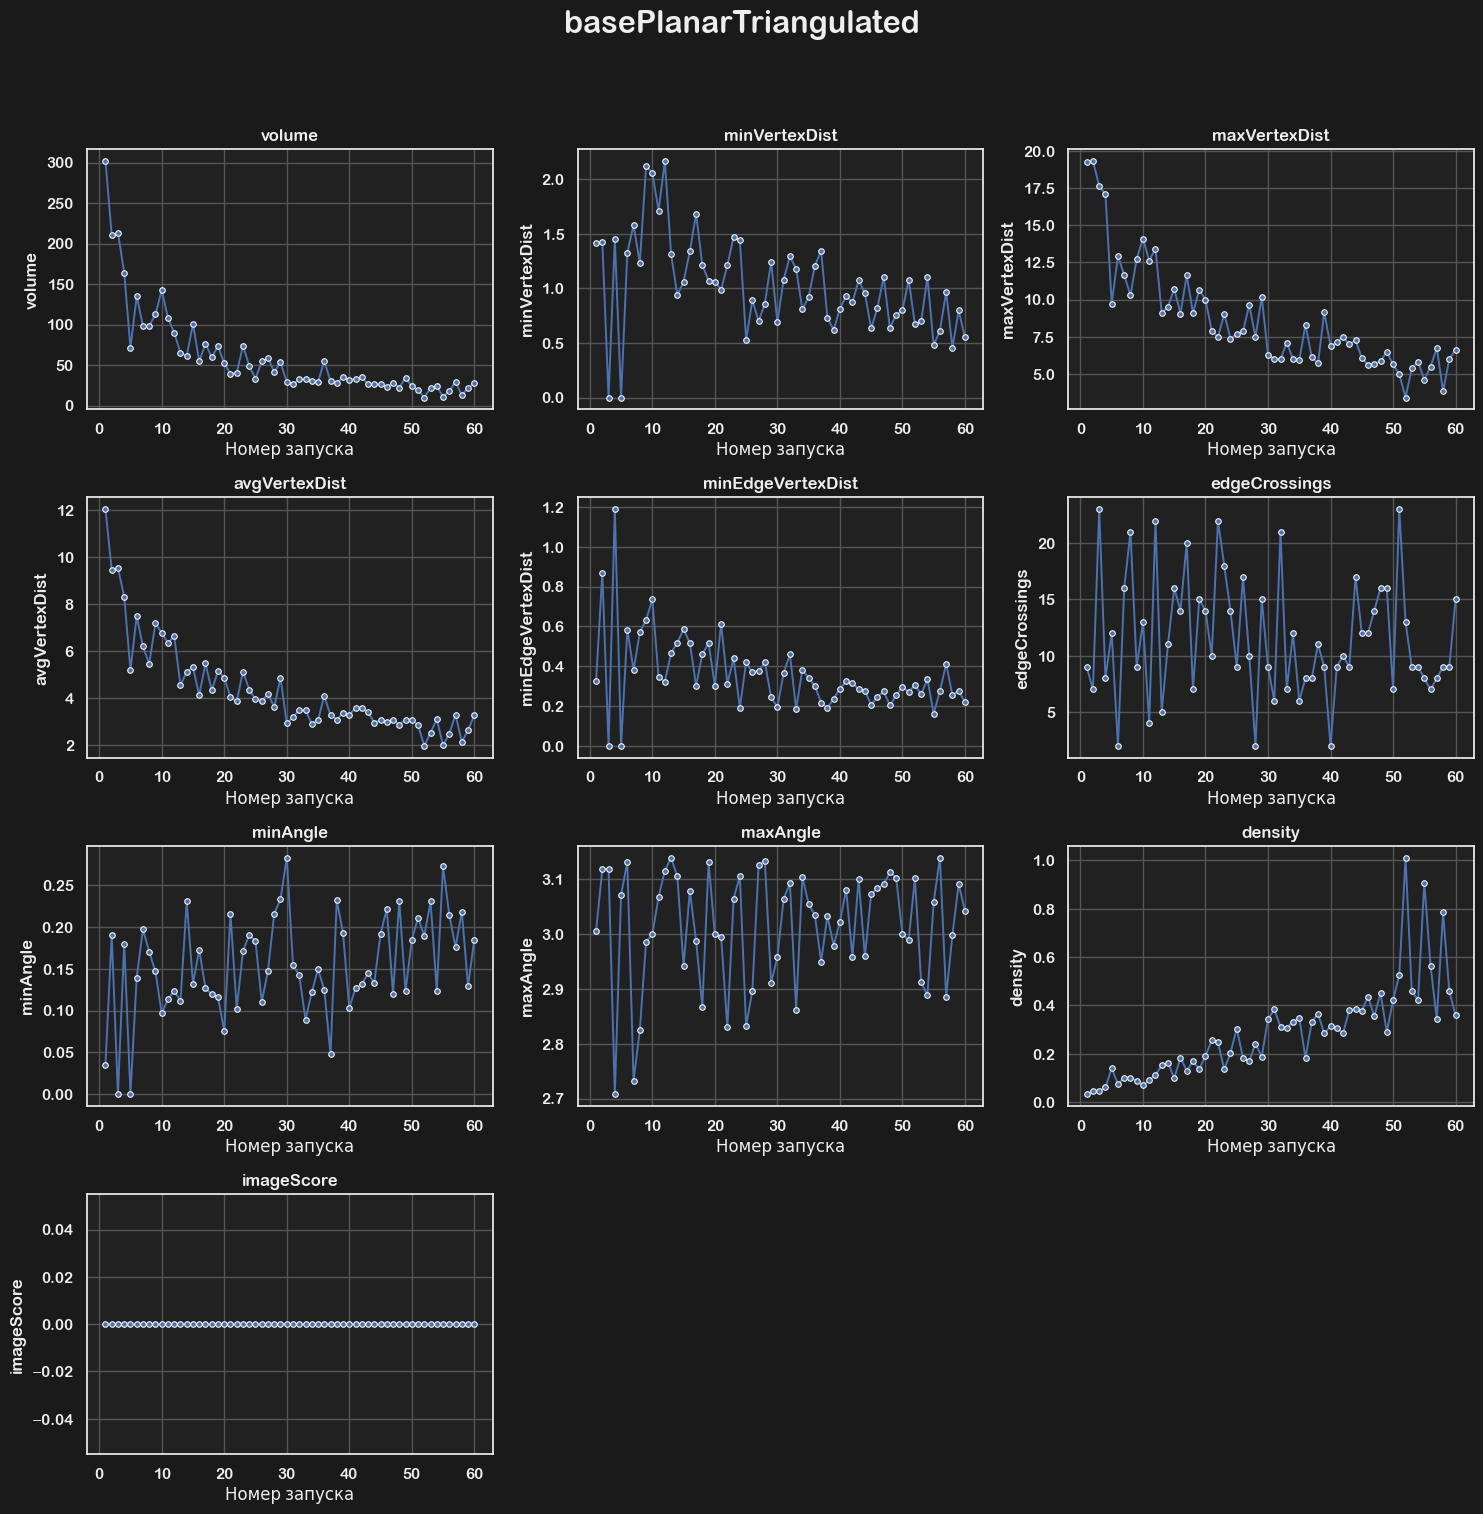

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


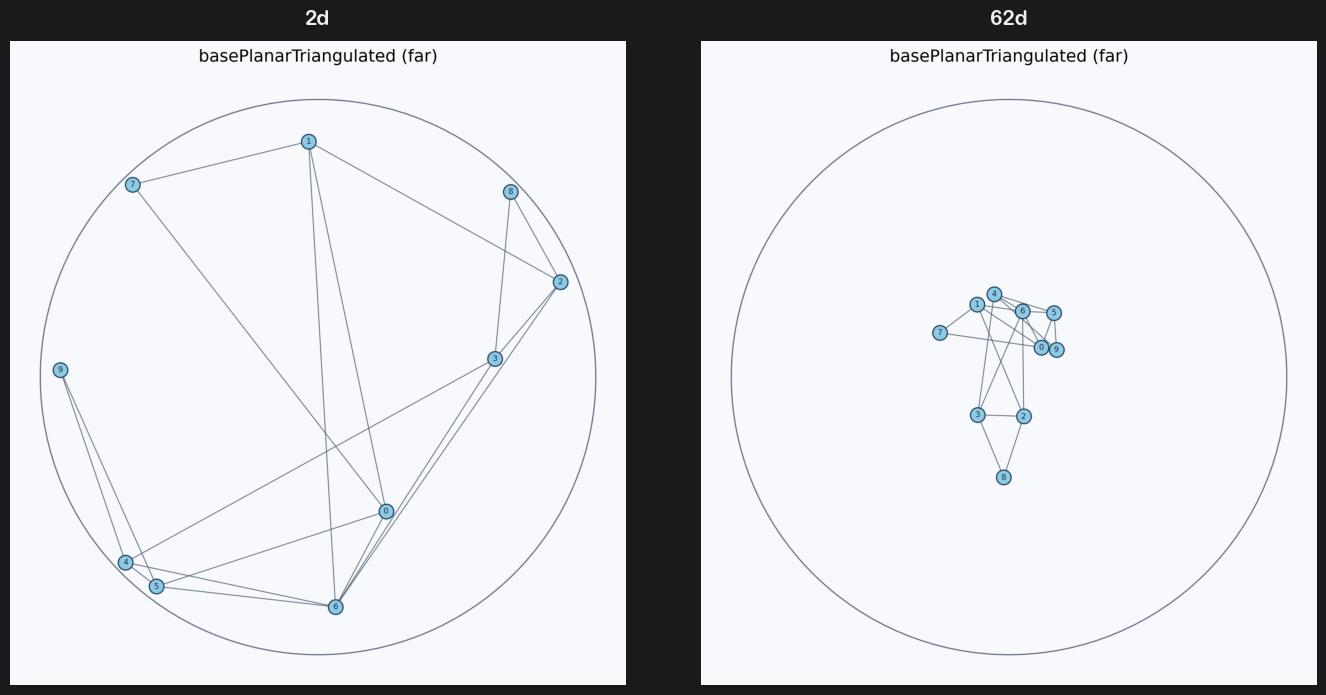

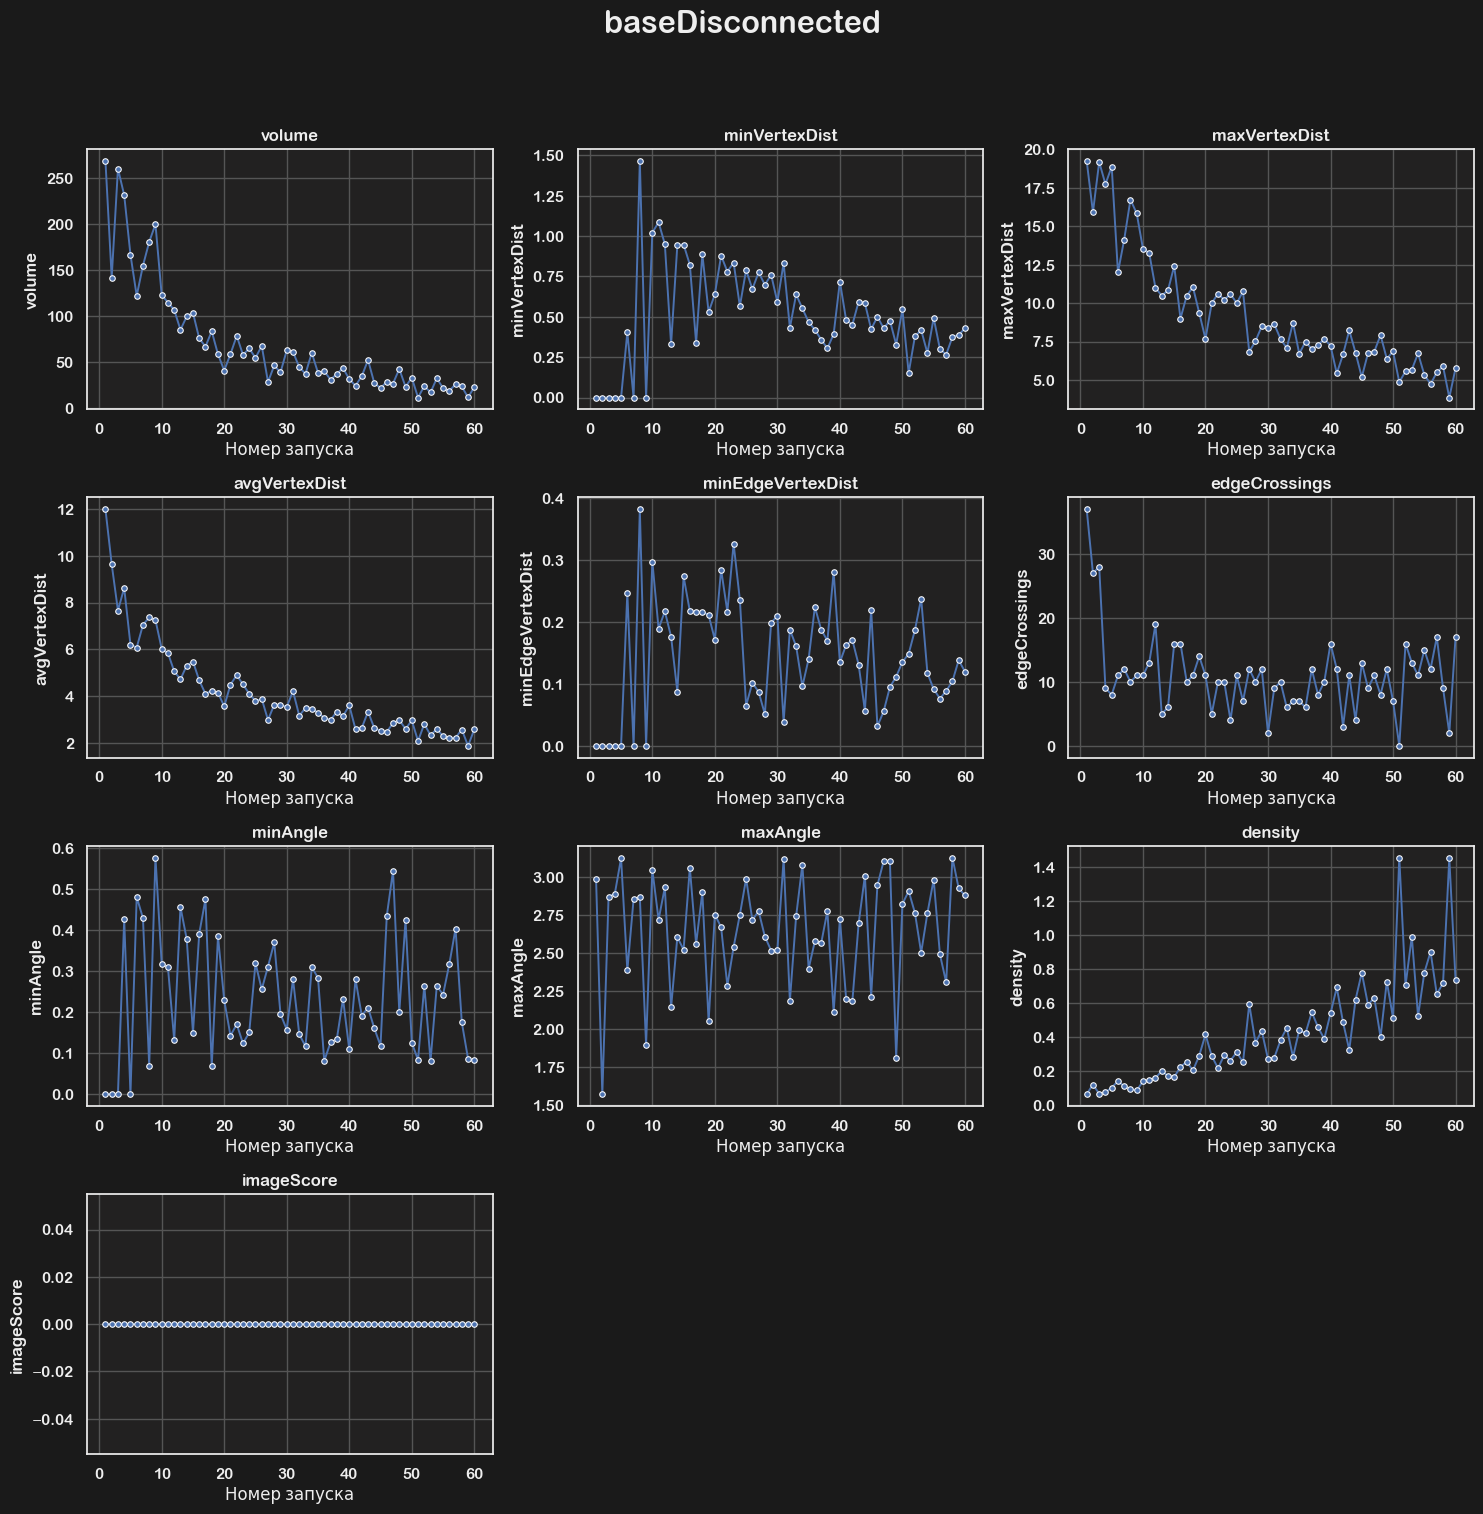

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


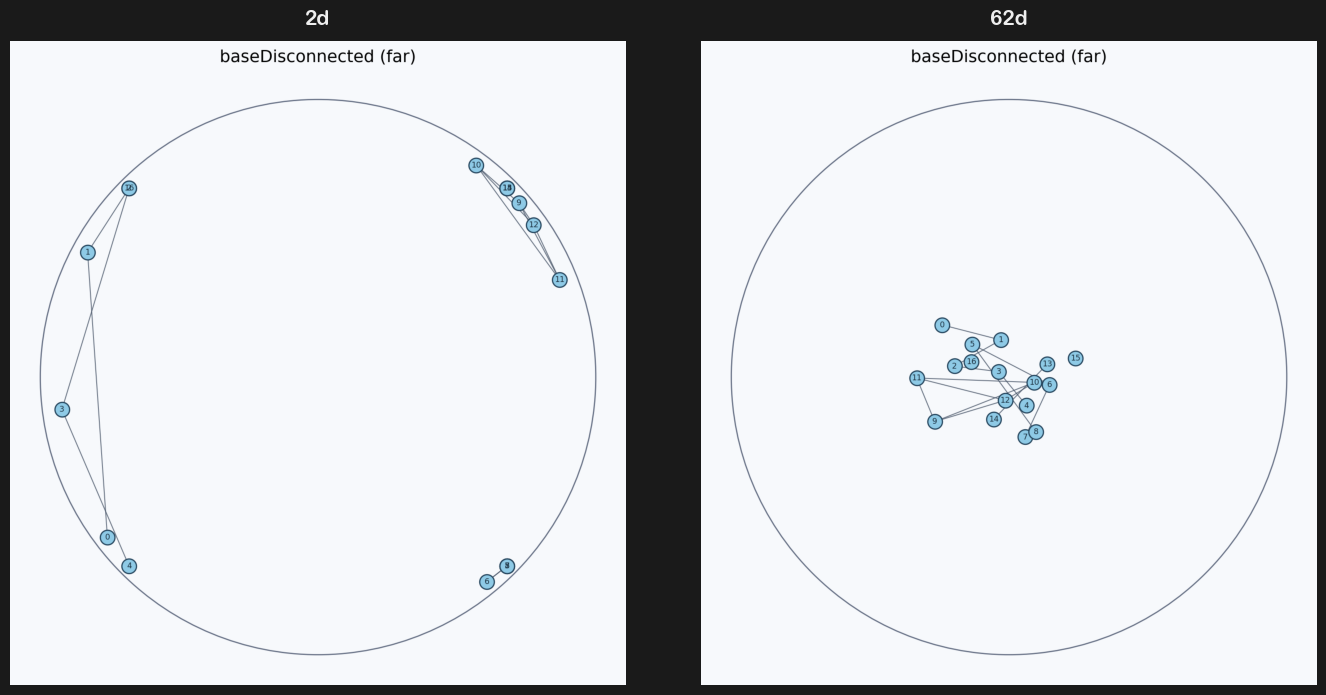

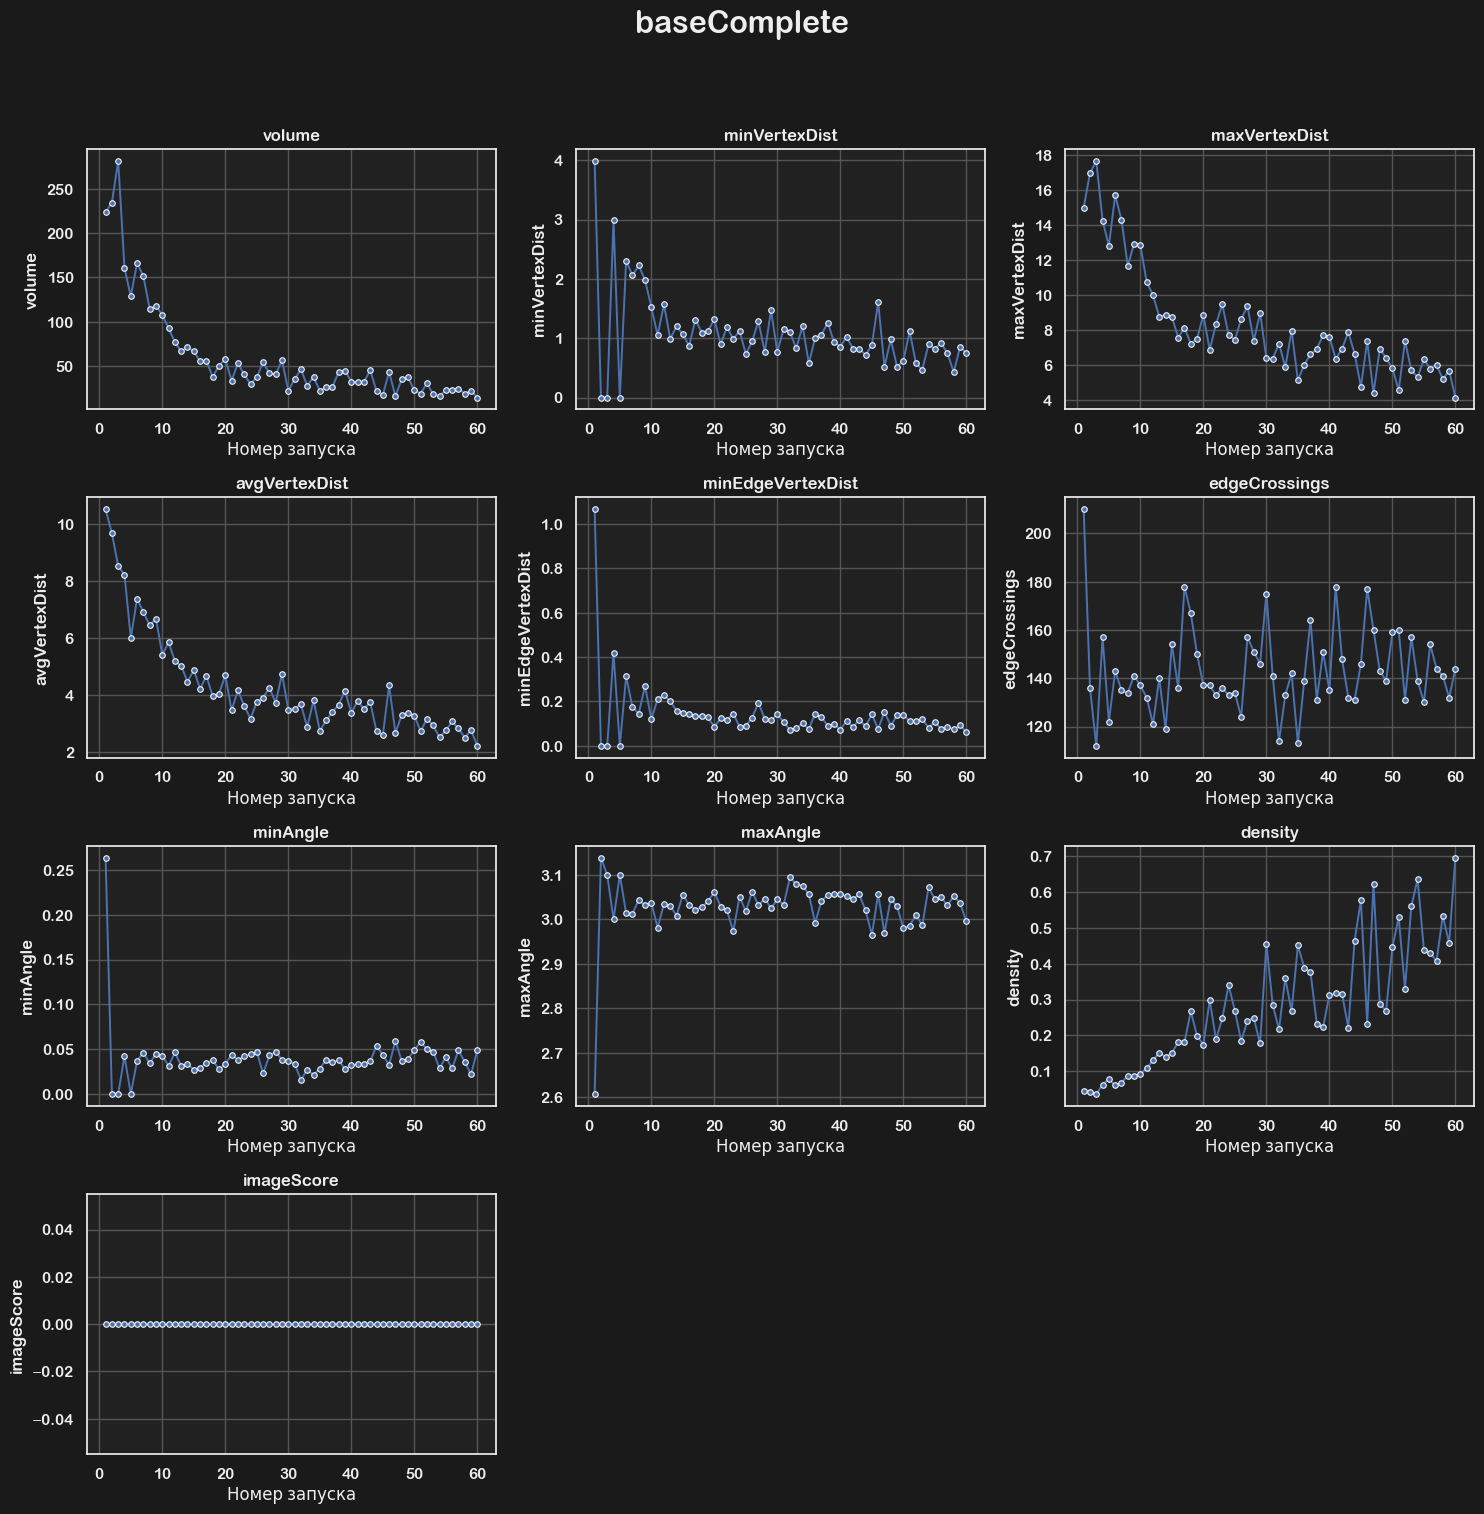

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


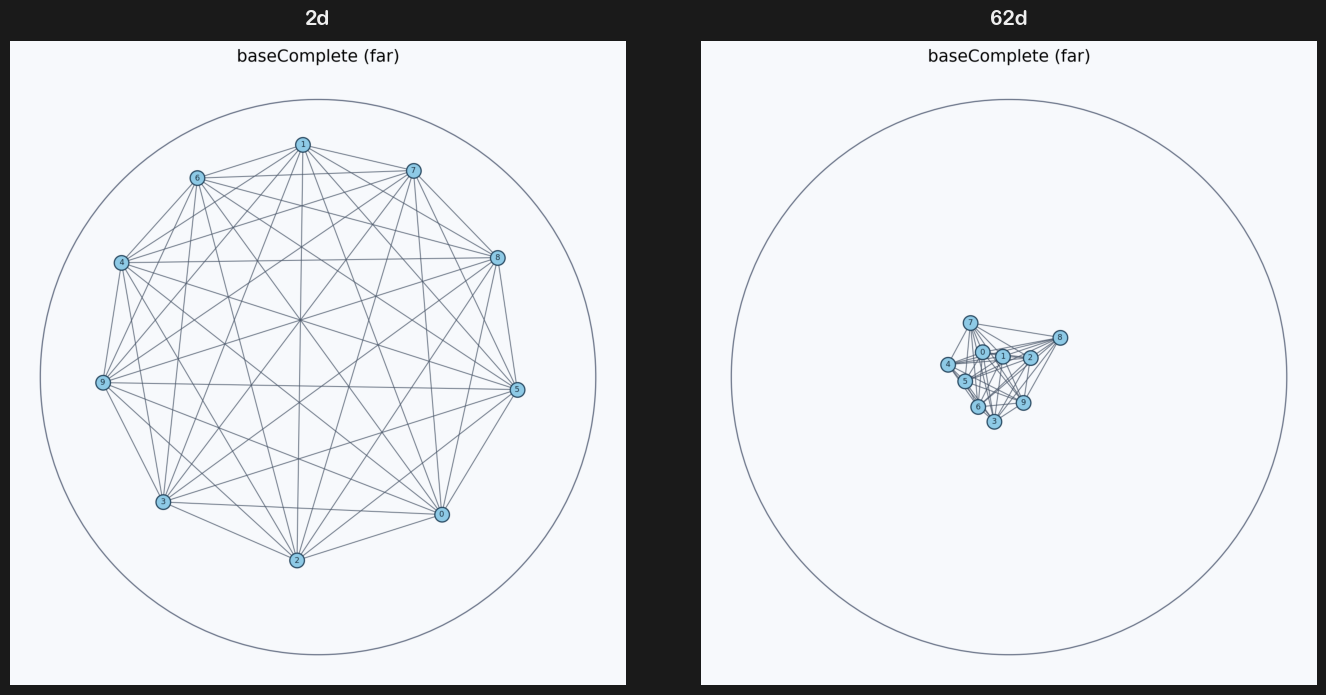

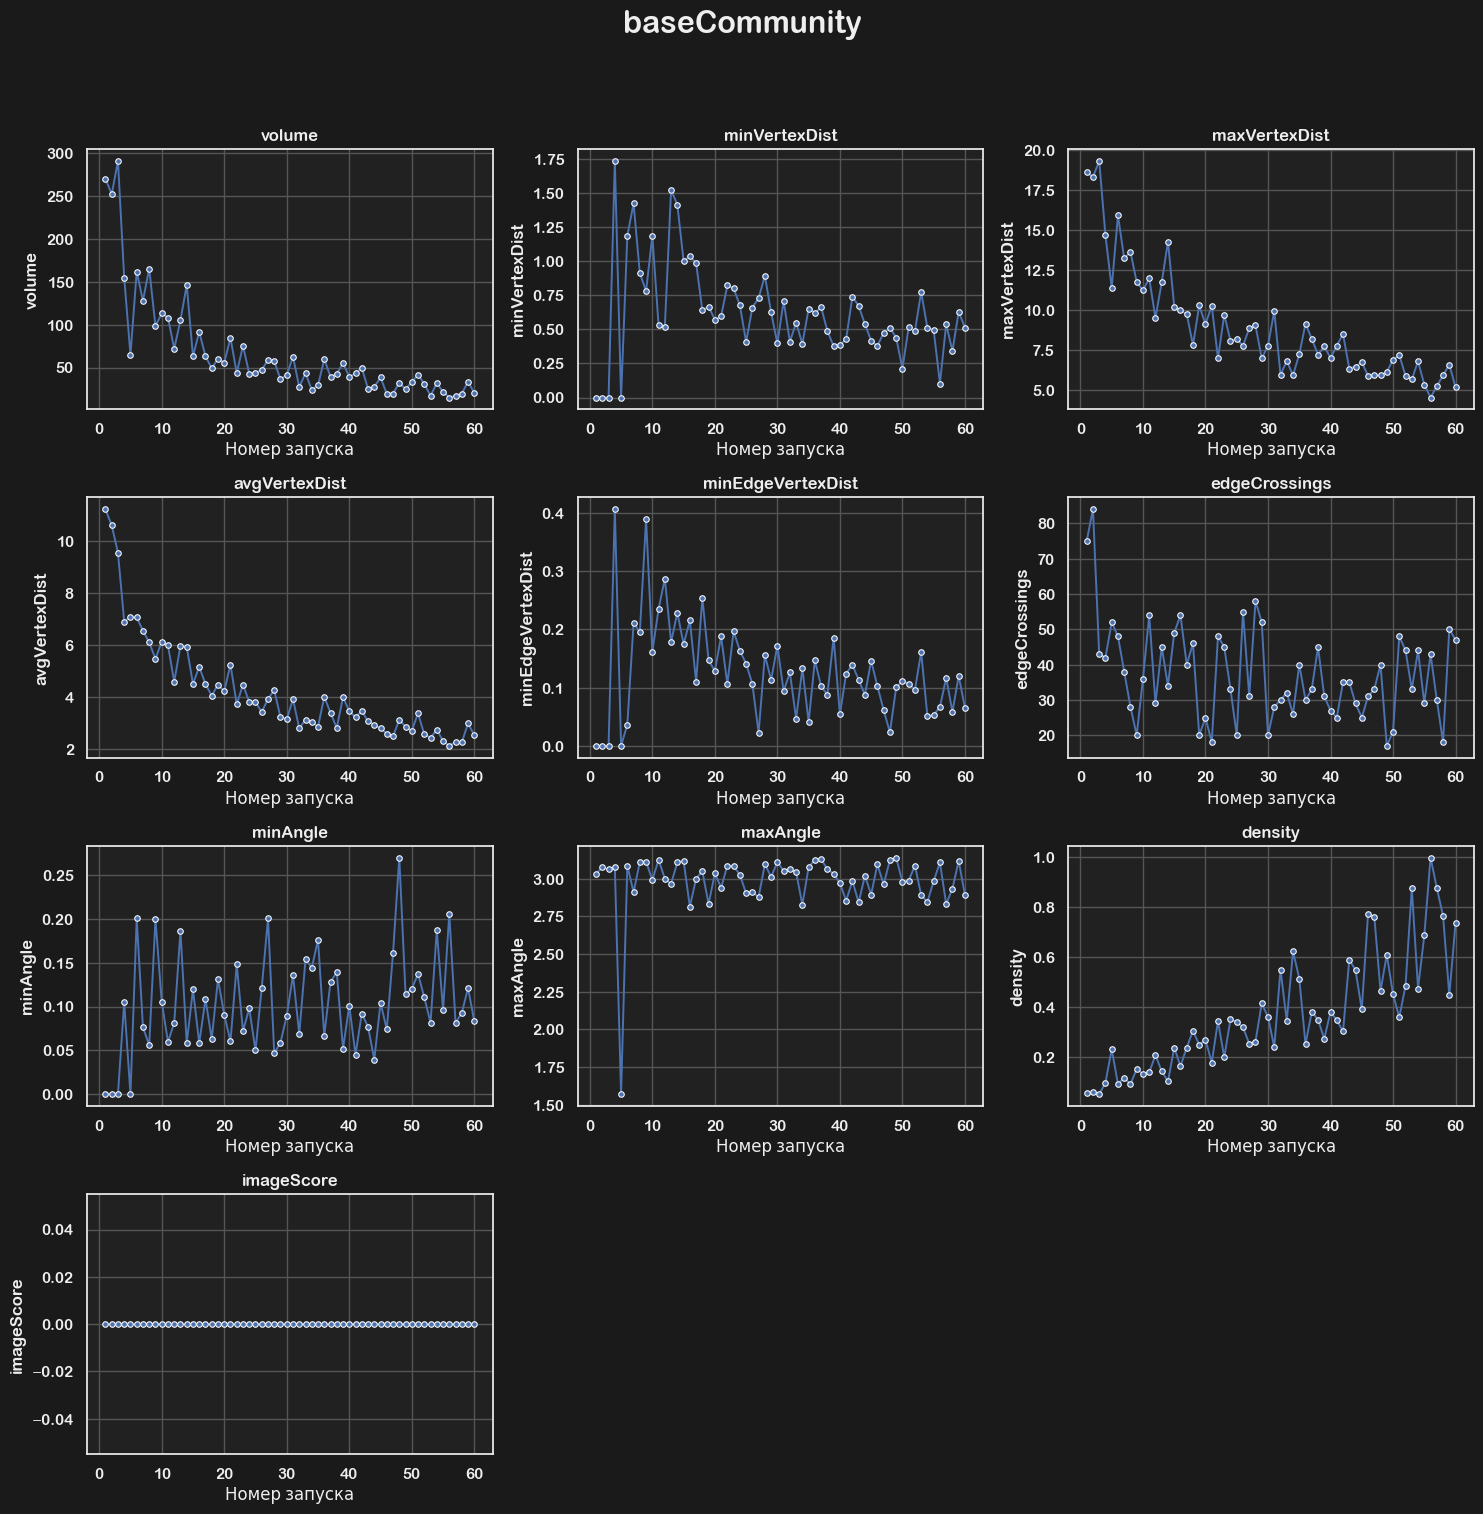

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_0.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/metrixFromDim/graph_batch_59.png


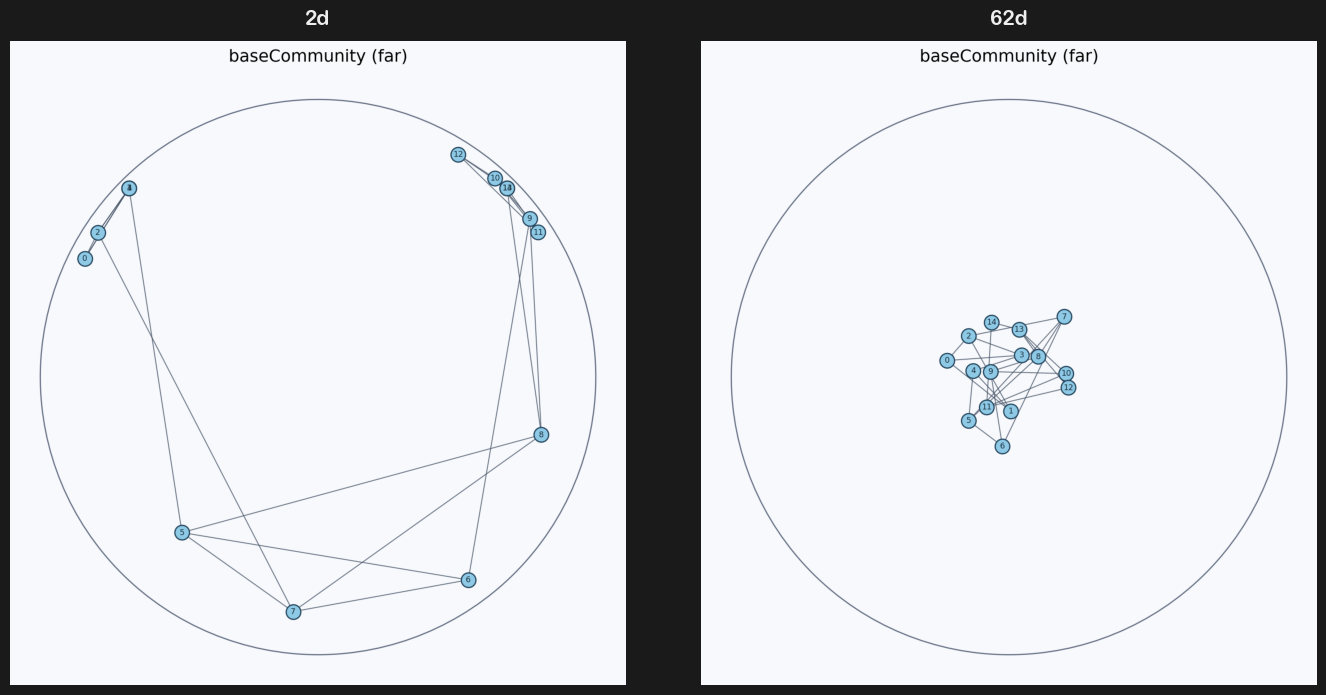

In [39]:
flags = [
    "--graph",
	"",
	"--algo",
	"far",
    "--initial-placement",
    "random",
    "--space",
    "hyperbolic",
    "--dim",
    "2",
    "--borderPolicy",
    "poly",
    "--projection",
    "kleinBestView",
    "--2d",
    "--FS",
    "20, 20",
    "--dataset",
    "samples/baseDataset.json",
	"--output",
	"out/notebook/far/metrixFromDim/graph.json",
    "--seed",
    "1543",
]

algoFlags = [
    "--C",
    "1.0",
    "--I",
    "100",
]

borderFlags = [
    "--S",
    "",
]

def flagsForRun(iters):
    for ind in iters:
        flags[9] = f"{ind + 2}"
        yield flags

def borderFlagsForRun(iters):
    for ind in iters:
        borderFlags[1] = ','.join(["5" for _ in range(ind + 2)])
        yield borderFlags

for gName in graphs:
    flags[1] = gName
    res = runTests(mainPath, flags=flags, n=60, flagsForRun=flagsForRun, algoFlags=algoFlags, borderFlags=borderFlags, borderFlagsForRun=borderFlagsForRun)
    plotMetrics(df=res, title=gName)
    p1 = renderRun(mainPath, res, 1)
    p2 = renderRun(mainPath, res, len(res))
    # print(res.columns)
    # print(res.head())
    displayTwo(p1, p2, title1="2d", title2="62d")
    
    
